# Padrões de risco para deteção de fraude


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Carregar base já limpa

In [3]:
file_path = "contratos_com_previsao.csv"
df = pd.read_csv(file_path, low_memory=False)

print("Dimensão da base:", df.shape)
display(df.head())

print("\nColunas disponíveis:")
print(df.columns.tolist())

Dimensão da base: (1803493, 51)


,idcontrato,tipoContrato,idprocedimento,tipoprocedimento,objectoContrato,descContrato,adjudicante,adjudicatarios,dataPublicacao,dataCelebracaoContrato,...,contrato_curto,fim_ano,is_ajuste_direto,is_concurso_publico,tem_acordo_quadro,cpv_str,cpv_3,cpv_4,preco_previsto_log,preco_previsto_modelo
0,60239,NaN,58870,Ajuste Direto Regime Geral,Prestação de serviços para Elaboração do Proje...,NaN,"501205551, MUNICIPIO DE CHAVES",JAIME JORGE ROCHA RODRIGUES,2009-06-05,NaN,...,1,0,1,0,0,NaN,NaN,NaN,8.743755,6270.398899
1,1336744,Aquisição de bens móveis,1335213,Ao abrigo de acordo-quadro (art. 259.),"Derivados do Plasma, AQ 2012/09",Kedrion,"508142156, CENTRO HOSPITALAR VILA NOVA DE GAIA...","508472830, KEDRION PORTUGAL DIST PROD FARM UNIP",2015-01-02,2015-01-02,...,0,0,0,0,1,33600000.0,336.0,3360.0,8.244238,3804.634358
2,1336799,Aquisição de bens móveis,1350653,Ao abrigo de acordo-quadro (art. 259.),"Seringas e Contentores, AQ 2012/22 (Renov 2020...",Overpharma,"508142156, CENTRO HOSPITALAR VILA NOVA DE GAIA...","505792362, OVERPHARMA",2015-01-02,2015-01-02,...,0,0,0,0,1,33100000.0,331.0,3310.0,9.068056,8672.747946
3,1336802,Aquisição de bens móveis,1350653,Ao abrigo de acordo-quadro (art. 259.),"Seringas e Contentores, AQ 2012/22 (Renov 2020...",PMH,"508142156, CENTRO HOSPITALAR VILA NOVA DE GAIA...","502376899, P M H PROD MEDICO HOSPITALARES",2015-01-02,2015-01-02,...,0,0,0,0,1,33100000.0,331.0,3310.0,9.068056,8672.747946
4,1336813,Aquisição de bens móveis,1337298,Ao abrigo de acordo-quadro (art. 259.),"Luvas para Uso Médico, AQ 2012/23 (Renov 2001614)",HR,"508142156, CENTRO HOSPITALAR VILA NOVA DE GAIA...","501895558, H R PRODUTOS QUIMICOS",2015-01-02,2015-01-02,...,0,0,0,0,1,33100000.0,331.0,3310.0,9.091646,8879.795308



Colunas disponíveis:
['idcontrato', 'tipoContrato', 'idprocedimento', 'tipoprocedimento', 'objectoContrato', 'descContrato', 'adjudicante', 'adjudicatarios', 'dataPublicacao', 'dataCelebracaoContrato', 'precoContratual', 'CPV', 'prazoExecucao', 'LocalExecucao', 'fundamentacao', 'ProcedimentoCentralizado', 'DescrAcordoQuadro', 'dataDecisaoAdjudicacao', 'regime', 'justifNReducEscrContrato', 'CritMateriais', 'concorrentes', 'linkPecasProc', 'Observacoes', 'ContratEcologico', 'fundamentAjusteDireto', 'Ano', 'ano_contrato', 'precoContratual_2025', 'setor_cpv', 'descricao_cpv', 'racio_preco_prazo', 'janela_eleicoes', 'AR', 'AL', 'ano_publicacao', 'mes_publicacao', 'dias_publicacao_decisao', 'n_concorrentes', 'log_prazoExecucao', 'contrato_longo', 'contrato_curto', 'fim_ano', 'is_ajuste_direto', 'is_concurso_publico', 'tem_acordo_quadro', 'cpv_str', 'cpv_3', 'cpv_4', 'preco_previsto_log', 'preco_previsto_modelo']


## 2. Ajustes mínimos para análise



In [4]:
# converter numéricos, se existirem
for col in ["precoContratual", "precoBaseProcedimento"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# converter datas, se existirem
if "dataPublicacao" in df.columns:
    df["dataPublicacao"] = pd.to_datetime(df["dataPublicacao"], errors="coerce")
    df["mes"] = df["dataPublicacao"].dt.month

# garantir CPV como texto e extrair setor CPV
if "CPV" in df.columns:
    df["CPV"] = df["CPV"].astype(str)
    df["setor_cpv"] = df["CPV"].str.extract(r"^(\d{2})")


display(df.head())

,idcontrato,tipoContrato,idprocedimento,tipoprocedimento,objectoContrato,descContrato,adjudicante,adjudicatarios,dataPublicacao,dataCelebracaoContrato,...,fim_ano,is_ajuste_direto,is_concurso_publico,tem_acordo_quadro,cpv_str,cpv_3,cpv_4,preco_previsto_log,preco_previsto_modelo,mes
0,60239,NaN,58870,Ajuste Direto Regime Geral,Prestação de serviços para Elaboração do Proje...,NaN,"501205551, MUNICIPIO DE CHAVES",JAIME JORGE ROCHA RODRIGUES,2009-06-05,NaN,...,0,1,0,0,NaN,NaN,NaN,8.743755,6270.398899,6
1,1336744,Aquisição de bens móveis,1335213,Ao abrigo de acordo-quadro (art. 259.),"Derivados do Plasma, AQ 2012/09",Kedrion,"508142156, CENTRO HOSPITALAR VILA NOVA DE GAIA...","508472830, KEDRION PORTUGAL DIST PROD FARM UNIP",2015-01-02,2015-01-02,...,0,0,0,1,33600000.0,336.0,3360.0,8.244238,3804.634358,1
2,1336799,Aquisição de bens móveis,1350653,Ao abrigo de acordo-quadro (art. 259.),"Seringas e Contentores, AQ 2012/22 (Renov 2020...",Overpharma,"508142156, CENTRO HOSPITALAR VILA NOVA DE GAIA...","505792362, OVERPHARMA",2015-01-02,2015-01-02,...,0,0,0,1,33100000.0,331.0,3310.0,9.068056,8672.747946,1
3,1336802,Aquisição de bens móveis,1350653,Ao abrigo de acordo-quadro (art. 259.),"Seringas e Contentores, AQ 2012/22 (Renov 2020...",PMH,"508142156, CENTRO HOSPITALAR VILA NOVA DE GAIA...","502376899, P M H PROD MEDICO HOSPITALARES",2015-01-02,2015-01-02,...,0,0,0,1,33100000.0,331.0,3310.0,9.068056,8672.747946,1
4,1336813,Aquisição de bens móveis,1337298,Ao abrigo de acordo-quadro (art. 259.),"Luvas para Uso Médico, AQ 2012/23 (Renov 2001614)",HR,"508142156, CENTRO HOSPITALAR VILA NOVA DE GAIA...","501895558, H R PRODUTOS QUIMICOS",2015-01-02,2015-01-02,...,0,0,0,1,33100000.0,331.0,3310.0,9.091646,8879.795308,1


## 3. Criar tabela base de empresas


In [5]:
# concorrentes explodidos
if "concorrentes" in df.columns:
    concorrentes_series = (
        df["concorrentes"]
        .dropna()
        .astype(str)
        .str.split("\n")
        .explode()
        .str.strip()
    )
    concorrentes_df = concorrentes_series.to_frame(name="empresa")
else:
    concorrentes_df = pd.DataFrame(columns=["empresa"])

# adjudicatários
if "adjudicatarios" in df.columns:
    adjudicatarios_df = (
        df["adjudicatarios"]
        .dropna()
        .astype(str)
        .str.strip()
        .to_frame(name="empresa")
    )
else:
    adjudicatarios_df = pd.DataFrame(columns=["empresa"])

# juntar
df_empresas = pd.concat([adjudicatarios_df, concorrentes_df], ignore_index=True)

df_empresas = (
    df_empresas
    .dropna()
    .loc[lambda x: x["empresa"] != ""]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Número de empresas únicas:", len(df_empresas))
display(df_empresas.head())

Número de empresas únicas: 171798


,empresa
0,JAIME JORGE ROCHA RODRIGUES
1,"508472830, KEDRION PORTUGAL DIST PROD FARM UNIP"
2,"505792362, OVERPHARMA"
3,"502376899, P M H PROD MEDICO HOSPITALARES"
4,"501895558, H R PRODUTOS QUIMICOS"


## 4. Contagens base por empresa

In [6]:
# total como adjudicatário
if "adjudicatarios" in df.columns:
    total_adjudicatario = (
        df["adjudicatarios"]
        .dropna()
        .astype(str)
        .str.strip()
        .value_counts()
    )
else:
    total_adjudicatario = pd.Series(dtype="int64")

# total como concorrente
if "concorrentes" in df.columns:
    total_concorrente = (
        df["concorrentes"]
        .dropna()
        .astype(str)
        .str.split("\n")
        .explode()
        .str.strip()
        .value_counts()
    )
else:
    total_concorrente = pd.Series(dtype="int64")

df_empresas["total_adjudicatario"] = df_empresas["empresa"].map(total_adjudicatario).fillna(0)
df_empresas["total_concorrente"] = df_empresas["empresa"].map(total_concorrente).fillna(0)
df_empresas["total_participacoes"] = (
    df_empresas["total_adjudicatario"] + df_empresas["total_concorrente"]
)

display(df_empresas.head())

,empresa,total_adjudicatario,total_concorrente,total_participacoes
0,JAIME JORGE ROCHA RODRIGUES,1.0,0.0,1.0
1,"508472830, KEDRION PORTUGAL DIST PROD FARM UNIP",381.0,328.0,709.0
2,"505792362, OVERPHARMA",8321.0,32524.0,40845.0
3,"502376899, P M H PROD MEDICO HOSPITALARES",2696.0,5717.0,8413.0
4,"501895558, H R PRODUTOS QUIMICOS",2772.0,8654.0,11426.0


# 8.3 Métodos e algoritmos

## 8.3.1 Maiores Perdedores



In [7]:
#calculo do rácio de derrotas
df_empresas["score_maiores_perdedores"] = np.where(
    df_empresas["total_participacoes"] > 0,
    df_empresas["total_concorrente"] / df_empresas["total_participacoes"],
    0
)

top_maiores_perdedores = (
    df_empresas[["empresa", "total_concorrente", "total_participacoes", "score_maiores_perdedores"]]
    .sort_values("score_maiores_perdedores", ascending=False)
    .reset_index(drop=True)
)

display(top_maiores_perdedores.head(20))

,empresa,total_concorrente,total_participacoes,score_maiores_perdedores
0,"514989220, COTECSOL",1.0,1.0,1.0
1,"504151827, RIBEIRA D ARCOS",1.0,1.0,1.0
2,"514970464, 14 ESTACOES",1.0,1.0,1.0
3,COSTA BRAS CONSTRUCOES DE JOSE MANUEL COSTA BRAS,1.0,1.0,1.0
4,"515607835, SIGMAVECTOR ENGENHARIA E CONSTRUCAO...",1.0,1.0,1.0
5,"515066702, RELAXPERFORMANCE",1.0,1.0,1.0
6,"514401885, ABC SAUDE",1.0,1.0,1.0
7,RVS RUI VAZ & SANTOS,1.0,1.0,1.0
8,"516150022, THERMOESTE SUMMER EXPECTATIONS",1.0,1.0,1.0
9,"513892478, RUMBAYER",1.0,1.0,1.0


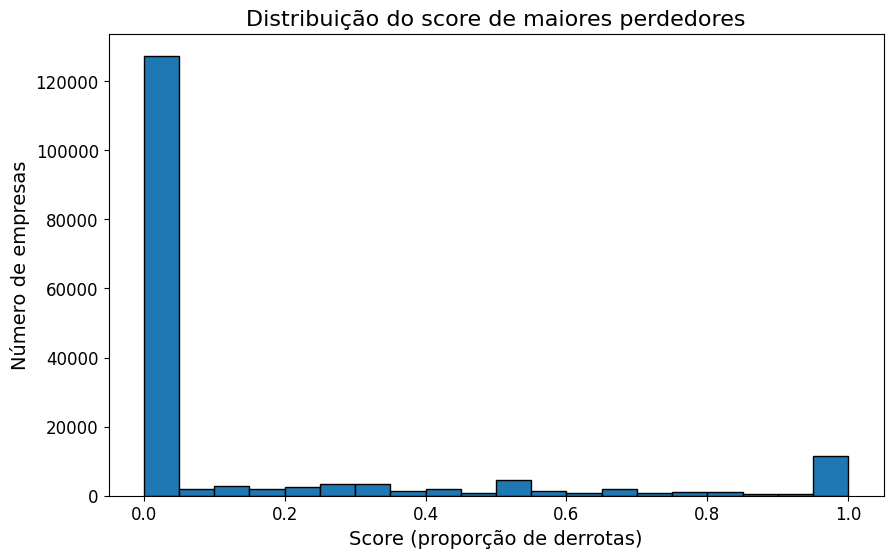

In [8]:
#gráfico de distribuição do score maiores perdedores
plt.figure(figsize=(10,6))

plt.hist(
    df_empresas["score_maiores_perdedores"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição do score de maiores perdedores", fontsize=16)
plt.xlabel("Score (proporção de derrotas)", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

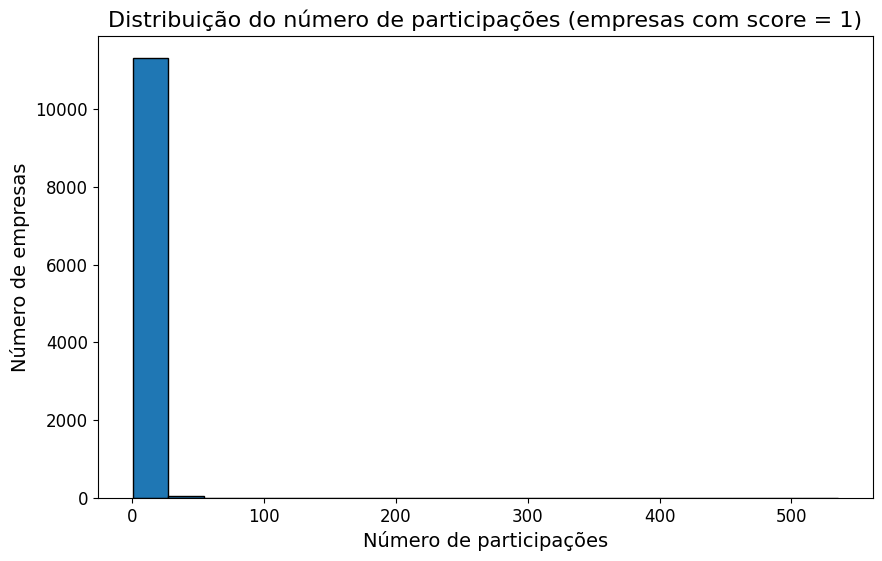

In [9]:
#gráfico de distribuição do número de participações para empresas com score 1
empresas_score1 = df_empresas[
    df_empresas["score_maiores_perdedores"] == 1
]

plt.figure(figsize=(10,6))

plt.hist(
    empresas_score1["total_participacoes"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição do número de participações (empresas com score = 1)", fontsize=16)
plt.xlabel("Número de participações", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

,empresa,total_participacoes,total_concorrente
161882,500697370,535.0,535.0
165427,"202298021, 8764 BAUSCH & LOMB EM PORTUGAL",177.0,177.0
166426,"516232134, MAPESO",152.0,152.0
166775,508107997,128.0,128.0
166776,508622263,128.0,128.0
161789,"502269537, G T S GRUPO TROFA SAUDE SGPS",102.0,102.0
162001,"513357475, AUTO MATEUS",85.0,85.0
161877,504451081,65.0,65.0
162181,AMELIA GONCALVES ALMENDRA RODRIGUES TIAGO LUIS...,64.0,64.0
163556,JONATHAN ANDRES ESTEVES DA SILVA JOANA RITA AR...,63.0,63.0


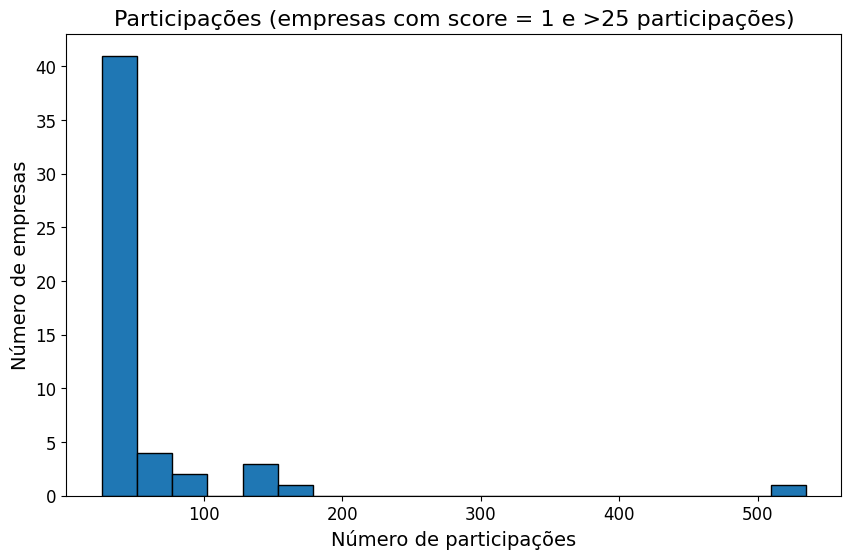

In [10]:
#Filtrar empresas com score = 1 e mais de 5 participações
empresas_score1_filtrado = df_empresas[
    (df_empresas["score_maiores_perdedores"] == 1) &
    (df_empresas["total_participacoes"] > 25)
]

#Ver tabela ordenada
display(
    empresas_score1_filtrado[
        ["empresa", "total_participacoes", "total_concorrente"]
    ].sort_values("total_participacoes", ascending=False)
)

#Histograma das participações
plt.figure(figsize=(10,6))

plt.hist(
    empresas_score1_filtrado["total_participacoes"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Participações (empresas com score = 1 e >25 participações)", fontsize=16)
plt.xlabel("Número de participações", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [11]:
# top empresas com score = 1
top_extremos = empresas_score1_filtrado.sort_values(
    "total_participacoes",
    ascending=False
)

# top 10
top10 = top_extremos.iloc[:10].copy()

# total de participações das empresas com score = 1
total_participacoes_score1 = (
    empresas_score1_filtrado["total_participacoes"]
    .sum()
)

# percentagem relativa ao total
top10["percentagem_total_score1"] = (
    top10["total_participacoes"] /
    total_participacoes_score1
) * 100

# tabela final
display(top10)

,empresa,total_adjudicatario,total_concorrente,total_participacoes,score_maiores_perdedores,percentagem_total_score1
161882,500697370,0.0,535.0,535.0,1.0,17.483660
165427,"202298021, 8764 BAUSCH & LOMB EM PORTUGAL",0.0,177.0,177.0,1.0,5.784314
166426,"516232134, MAPESO",0.0,152.0,152.0,1.0,4.967320
166775,508107997,0.0,128.0,128.0,1.0,4.183007
166776,508622263,0.0,128.0,128.0,1.0,4.183007
161789,"502269537, G T S GRUPO TROFA SAUDE SGPS",0.0,102.0,102.0,1.0,3.333333
162001,"513357475, AUTO MATEUS",0.0,85.0,85.0,1.0,2.777778
161877,504451081,0.0,65.0,65.0,1.0,2.124183
162181,AMELIA GONCALVES ALMENDRA RODRIGUES TIAGO LUIS...,0.0,64.0,64.0,1.0,2.091503
163556,JONATHAN ANDRES ESTEVES DA SILVA JOANA RITA AR...,0.0,63.0,63.0,1.0,2.058824


In [12]:

empresa_target = "500697370, PETROLEOS DE PORTUGAL PETROGAL"

resultado = df_empresas[
    df_empresas["empresa"].str.strip() == empresa_target.strip()
][
    [
        "empresa",
        "total_concorrente",
        "total_adjudicatario",
        "total_participacoes",
        "score_maiores_perdedores",
        
    ]
]

display(resultado)

,empresa,total_concorrente,total_adjudicatario,total_participacoes,score_maiores_perdedores
601,"500697370, PETROLEOS DE PORTUGAL PETROGAL",3295.0,5811.0,9106.0,0.361849


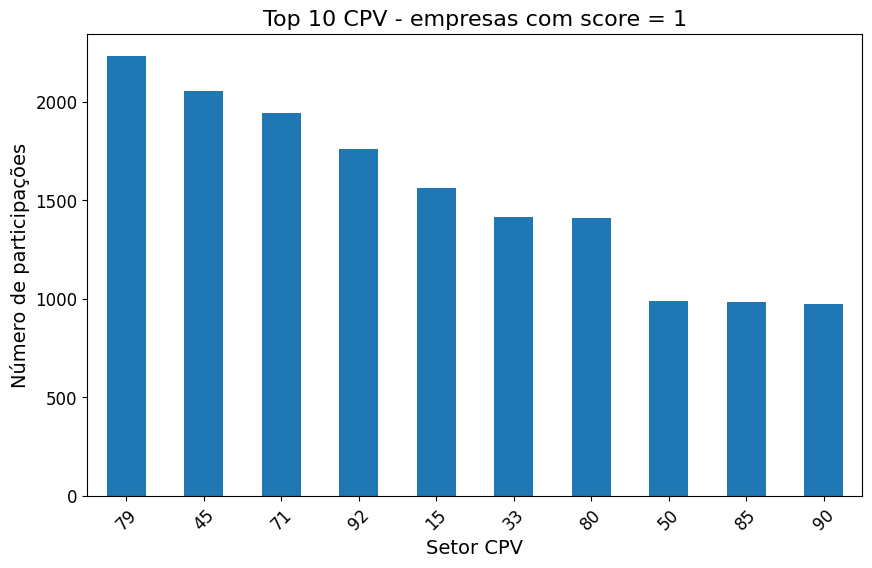

In [13]:

#todas as empresas com score = 1
lista_empresas = df_empresas[
    df_empresas["score_maiores_perdedores"] == 1
]["empresa"].unique()

#Explodir concorrentes
df_concorrentes = (
    df[df["concorrentes"].notna()]
    .assign(empresa=lambda x: x["concorrentes"].str.split("\n"))
    .explode("empresa")
)

df_concorrentes["empresa"] = df_concorrentes["empresa"].str.strip()

#Filtrar só essas empresas

df_suspeitos = df_concorrentes[
    df_concorrentes["empresa"].isin(lista_empresas)
]

#Plot CPV

plt.figure(figsize=(10,6))

df_suspeitos["setor_cpv"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 CPV - empresas com score = 1", fontsize=16)
plt.xlabel("Setor CPV", fontsize=14)
plt.ylabel("Número de participações", fontsize=14)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

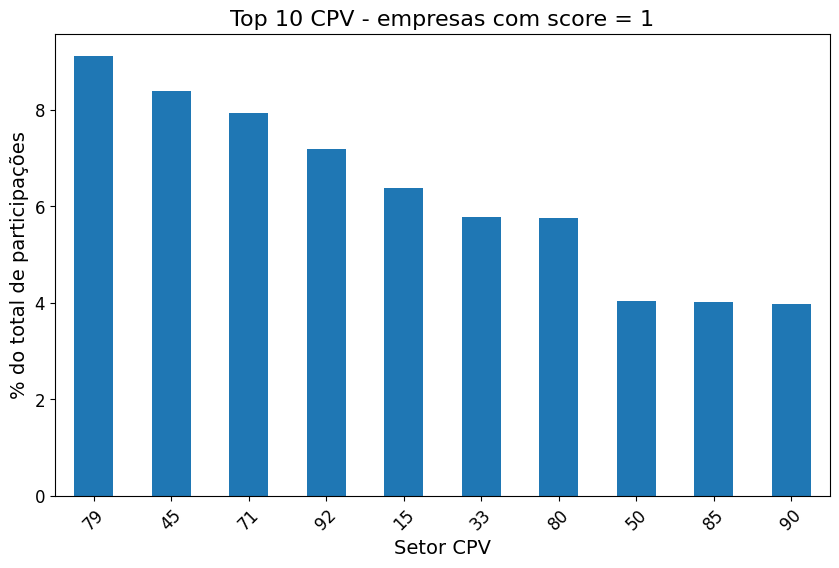

In [14]:
# todas as empresas com score = 1
lista_empresas = df_empresas[
    df_empresas["score_maiores_perdedores"] == 1
]["empresa"].unique()

# explodir concorrentes
df_concorrentes = (
    df[df["concorrentes"].notna()]
    .assign(empresa=lambda x: x["concorrentes"].str.split("\n"))
    .explode("empresa")
)

df_concorrentes["empresa"] = (
    df_concorrentes["empresa"].str.strip()
)

# filtrar só essas empresas
df_suspeitos = df_concorrentes[
    df_concorrentes["empresa"].isin(lista_empresas)
]

# contagem por CPV
cpv_counts = (
    df_suspeitos["setor_cpv"]
    .value_counts()
    .head(10)
)

# percentagem relativa ao total
cpv_percent = (
    cpv_counts / len(df_suspeitos)
) * 100

# plot
plt.figure(figsize=(10,6))

cpv_percent.plot(kind="bar")

plt.title(
    "Top 10 CPV - empresas com score = 1",
    fontsize=16
)

plt.xlabel("Setor CPV", fontsize=14)
plt.ylabel("% do total de participações", fontsize=14)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [15]:

#Top CPVs do gráfico
top_cpvs = df_suspeitos["setor_cpv"].value_counts().head(10).index.tolist()

#Filtrar o df original para esses CPVs
df_cpvs = df[df["setor_cpv"].isin(top_cpvs)].copy()

#Extrair descrição do CPV
df_cpvs["descricao_cpv"] = df_cpvs["CPV"].str.split("-").str[2]


# 1 EXEMPLO POR CPV

exemplos = (
    df_cpvs
    .dropna(subset=["descricao_cpv"])
    .groupby("setor_cpv")
    .first()[
        [
            "CPV",
            "descricao_cpv",
            "adjudicante",
            "adjudicatarios",
            "precoContratual"
        ]
    ]
    .reset_index()
)

display(exemplos)

,setor_cpv,CPV,descricao_cpv,adjudicante,adjudicatarios,precoContratual
0,15,15800000-6 - Produtos alimentares diversos,Produtos alimentares diversos,"600075664, AGRUPAMENTO DE ESCOLAS DE ANTONIO F...","502388803, VANIBRU COMERCIO DE PRODUTOS ALIMEN...",2924.80
1,33,33600000-6 - Produtos farmacêuticos,Produtos farmacêuticos,"508142156, CENTRO HOSPITALAR VILA NOVA DE GAIA...","508472830, KEDRION PORTUGAL DIST PROD FARM UNIP",40.50
2,45,45232400-6 - Obras de construção de esgotos,Obras de construção de esgotos,"501294104, MUNICIPIO DE SETUBAL","501369295, CME CONSTRUCAO E MANUTENCAO ELECTRO...",19052.43
3,50,50750000-7 - Serviços de manutenção de elevadores,Serviços de manutenção de elevadores,"600039366, SERVICOS DE ACCAO SOCIAL DA UNIVERS...","500230757, SCHMITT ELEVADORES",2660.00
4,71,71310000-4 - Serviços de consultoria em matéri...,Serviços de consultoria em matéria de engenha...,"503956546, MUNICIPIO DE BORBA","507862007, JOAO GIGA SERVICOS DE ENGENHARIA",6000.00
5,79,79212000-3 - Serviços de auditoria,Serviços de auditoria,"511027281, SOFATI SOCIEDADE FORMACAO E APLICAC...","503848522, J CAMILO & ASSOCIADOS SROC",3500.00
6,80,80500000-9 - Serviços de formação,Serviços de formação,"511027303, ASSOCIACAO DE MUNICIPIOS DA REGIAO ...","503586730, QUADROS E METAS CONSULTORES DE GEST...",19400.00
7,85,85121270-6 - Serviços de psiquiatria ou psicol...,Serviços de psiquiatria ou psicologia,"506613461, MUNICIPIO DE VILA VICOSA",MARIA JOAO CARDOSO DAVID,5818.80
8,90,90911200-8 - Serviços de limpeza de edifícios,Serviços de limpeza de edifícios,"600077179, AGRUPAMENTO DE ESCOLAS DE PARDILHO","506278522, FERLIMPA 2 LIMPEZAS GERAIS E MANUTE...",11330.00
9,92,92512000-3 - Serviços dos arquivos,Serviços dos arquivos,"506613461, MUNICIPIO DE VILA VICOSA",LUIS ALBERTO ROSA VAZ,7558.80


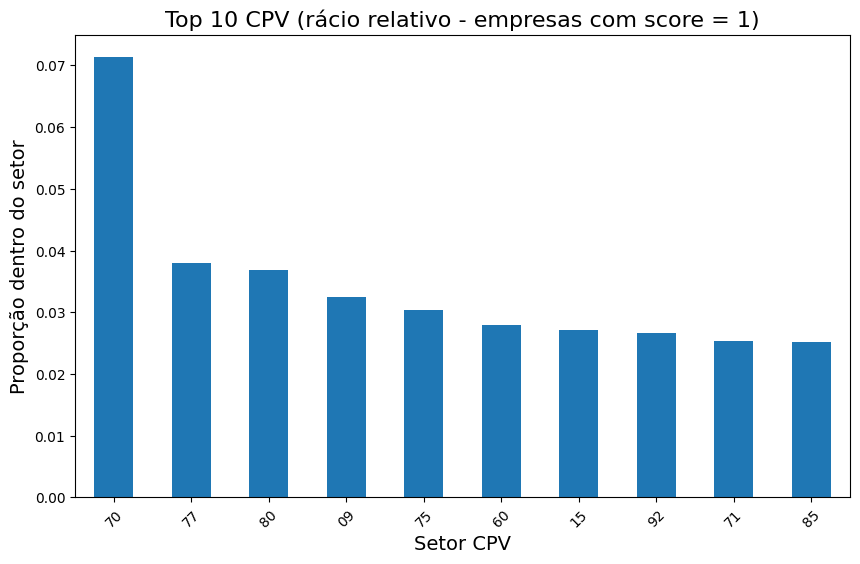

In [16]:
#total de contratos por CPV (base toda)
total_cpv = df["setor_cpv"].value_counts()

#Participações das empresas com score = 1
cpv_suspeitos = df_suspeitos["setor_cpv"].value_counts()

#Rácio
ratio_cpv = (cpv_suspeitos / total_cpv).dropna().sort_values(ascending=False)

#Plot
plt.figure(figsize=(10,6))
ratio_cpv.head(10).plot(kind="bar")

plt.title("Top 10 CPV (rácio relativo - empresas com score = 1)", fontsize=16)
plt.xlabel("Setor CPV", fontsize=14)
plt.ylabel("Proporção dentro do setor", fontsize=14)

plt.xticks(rotation=45)
plt.show()

In [17]:
# pegar lista dos CPVs do gráfico (top 10 do rácio)
top_cpv_codigos = ratio_cpv.head(10).index.tolist()

# criar coluna com descrição do CPV (se ainda não tiveres)
df["cpv_descricao"] = df["CPV"].astype(str)

# extrair um exemplo de descrição por setor (2 dígitos)
cpv_exemplos = (
    df[df["setor_cpv"].isin(top_cpv_codigos)]
    .dropna(subset=["cpv_descricao"])
    .drop_duplicates(subset=["setor_cpv"])
    [["setor_cpv", "cpv_descricao"]]
    .sort_values("setor_cpv")
)

display(cpv_exemplos)

,setor_cpv,cpv_descricao
144,09,09132000-3 - Gasolina
71,15,15800000-6 - Produtos alimentares diversos
186,60,60180000-3 - Aluguer de veículos para transpor...
1156,70,70311000-4 - Serviços de venda ou arrendamento...
104,71,71310000-4 - Serviços de consultoria em matéri...
92,75,75231240-8 - Serviços de reinserção social e p...
85,77,77311000-3 - Serviços de manutenção de jardins...
220,80,80500000-9 - Serviços de formação
129,85,85121270-6 - Serviços de psiquiatria ou psicol...
123,92,92512000-3 - Serviços dos arquivos


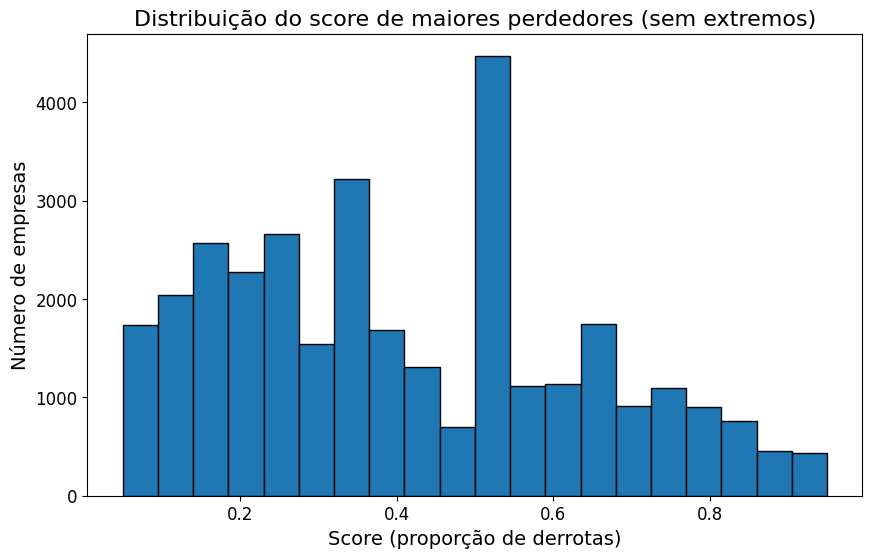

In [18]:
# remover scores muito próximos de 0 e 1
df_filtrado = df_empresas[
    (df_empresas["score_maiores_perdedores"] > 0.05) &
    (df_empresas["score_maiores_perdedores"] < 0.95)
]

plt.figure(figsize=(10,6))

plt.hist(
    df_filtrado["score_maiores_perdedores"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição do score de maiores perdedores (sem extremos)", fontsize=16)
plt.xlabel("Score (proporção de derrotas)", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

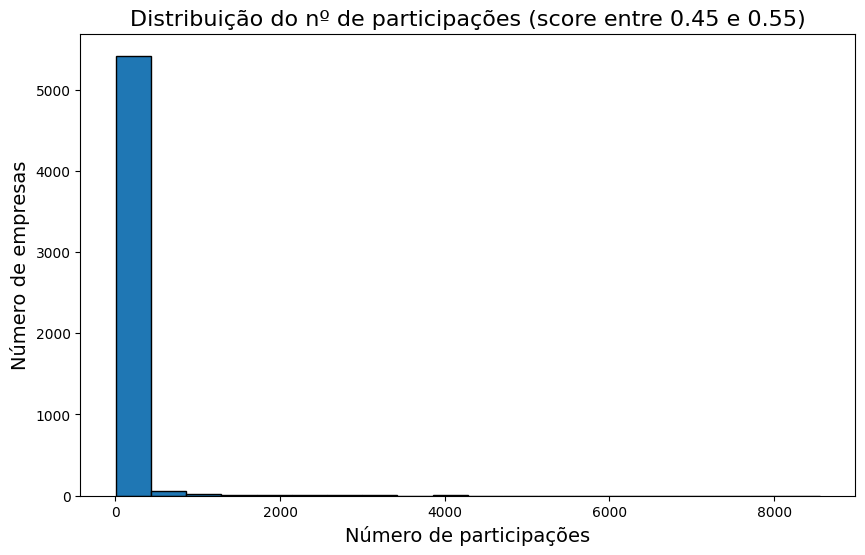

In [19]:
empresas_meio = df_empresas[
    (df_empresas["score_maiores_perdedores"] >= 0.45) &
    (df_empresas["score_maiores_perdedores"] <= 0.55)
]

plt.figure(figsize=(10,6))

plt.hist(
    empresas_meio["total_participacoes"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição do nº de participações (score entre 0.45 e 0.55)", fontsize=16)
plt.xlabel("Número de participações", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.show()

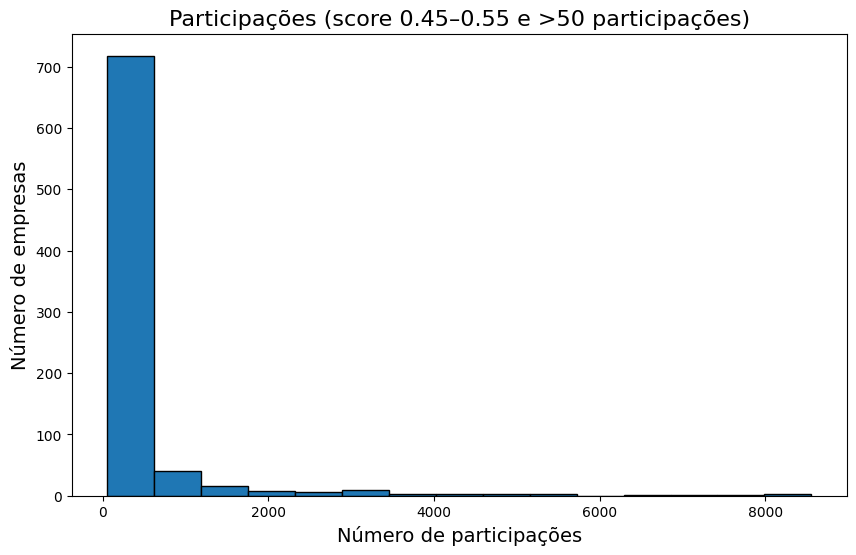

In [20]:
empresas_meio_relevantes = df_empresas[
    (df_empresas["score_maiores_perdedores"] >= 0.45) &
    (df_empresas["score_maiores_perdedores"] <= 0.55) &
    (df_empresas["total_participacoes"] > 50)
]

plt.figure(figsize=(10,6))

plt.hist(
    empresas_meio_relevantes["total_participacoes"].dropna(),
    bins=15,
    edgecolor="black"
)

plt.title("Participações (score 0.45–0.55 e >50 participações)", fontsize=16)
plt.xlabel("Número de participações", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.show()

## 8.3.2 Custo Elevado



In [21]:

#Rácio de custo por contrato

df["ratio_custo"] = np.where(
    df["preco_previsto_modelo"] > 0,
    df["precoContratual_2025"] / df["preco_previsto_modelo"],
    np.nan
)

#Média do rácio por empresa

custo_empresa = (
    df.dropna(subset=["adjudicatarios", "ratio_custo"])
      .groupby("adjudicatarios")["ratio_custo"]
      .mean()
)


#juntar ao df_empresas
df_empresas["ratio_custo_medio"] = (
    df_empresas["empresa"].map(custo_empresa)
)

#Criar score com ranking percentil
df_empresas["score_custo_elevado"] = (
    df_empresas["ratio_custo_medio"]
    .rank(method="average", pct=True)
)


#Tratar NA's

df_empresas["score_custo_elevado"] = df_empresas["score_custo_elevado"].fillna(0)

display(df_empresas.head(20))

,empresa,total_adjudicatario,total_concorrente,total_participacoes,score_maiores_perdedores,ratio_custo_medio,score_custo_elevado
0,JAIME JORGE ROCHA RODRIGUES,1.0,0.0,1.0,0.000000,2.371365,0.866761
1,"508472830, KEDRION PORTUGAL DIST PROD FARM UNIP",381.0,328.0,709.0,0.462623,14.811812,0.996368
2,"505792362, OVERPHARMA",8321.0,32524.0,40845.0,0.796279,2.137005,0.832924
3,"502376899, P M H PROD MEDICO HOSPITALARES",2696.0,5717.0,8413.0,0.679544,2.311340,0.859072
4,"501895558, H R PRODUTOS QUIMICOS",2772.0,8654.0,11426.0,0.757395,1.614109,0.699828
5,"500684324, MEDICINALIA CORMEDICA",6049.0,8705.0,14754.0,0.590009,3.299158,0.933050
6,"505001764, ELECTRO REQUETIM DISTRIBUICAO DE MA...",83.0,28.0,111.0,0.252252,2.014952,0.810014
7,"508080975, RICOH PORTUGAL",279.0,249.0,528.0,0.471591,1.653384,0.713445
8,"503047201, CSL BEHRING",2227.0,1820.0,4047.0,0.449716,10.894935,0.993316
9,"502041285, GRIFOLS PORTUGAL",2595.0,3067.0,5662.0,0.541681,5.539495,0.975736


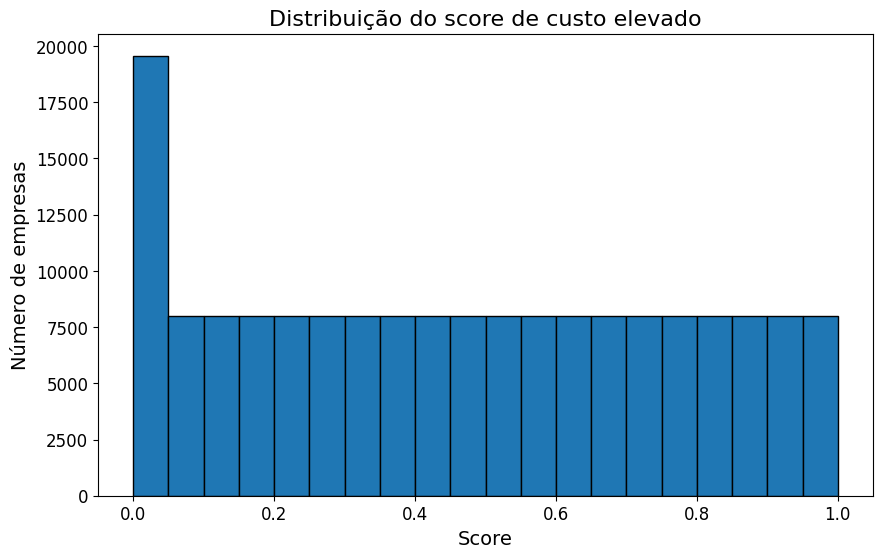

In [22]:
plt.figure(figsize=(10,6))

plt.hist(
    df_empresas["score_custo_elevado"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição do score de custo elevado", fontsize=16)
plt.xlabel("Score", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

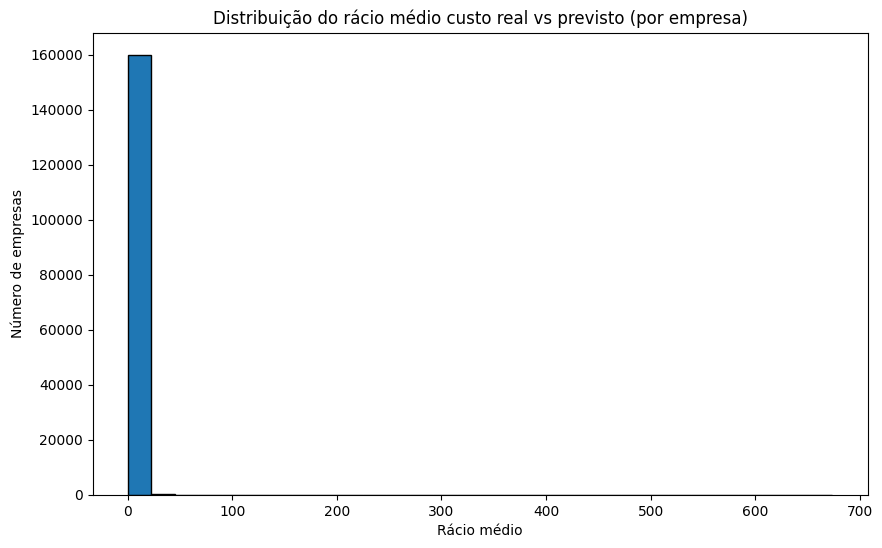

In [23]:
plt.figure(figsize=(10,6))

plt.hist(
    df_empresas["ratio_custo_medio"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribuição do rácio médio custo real vs previsto (por empresa)")
plt.xlabel("Rácio médio")
plt.ylabel("Número de empresas")

plt.show()

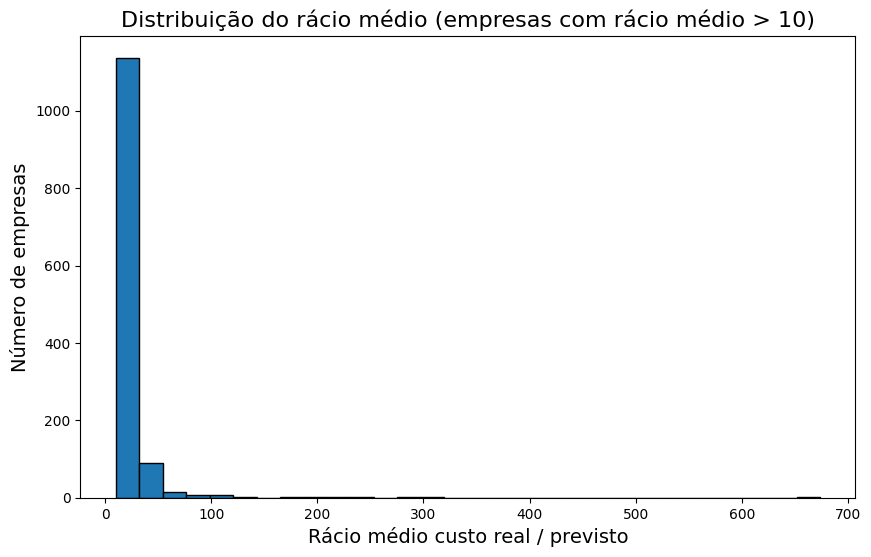

In [24]:
df_alto = df_empresas[
    df_empresas["ratio_custo_medio"] > 10
]

plt.figure(figsize=(10,6))

plt.hist(
    df_alto["ratio_custo_medio"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribuição do rácio médio (empresas com rácio médio > 10)", fontsize=16)
plt.xlabel("Rácio médio custo real / previsto", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.show()

In [25]:
# rácio médio por CPV
ratio_medio_cpv = (
    df.groupby("setor_cpv")["ratio_custo"]
    .mean()
    .reset_index(name="ratio_medio_cpv")
)

# CPV principal de cada empresa
cpv_empresa = (
    df.groupby(["adjudicatarios", "setor_cpv"])
    .size()
    .reset_index(name="n")
)

idx = cpv_empresa.groupby("adjudicatarios")["n"].idxmax()

cpv_principal = (
    cpv_empresa.loc[idx, ["adjudicatarios", "setor_cpv"]]
    .rename(columns={
        "adjudicatarios": "empresa",
        "setor_cpv": "cpv_principal"
    })
)

# juntar rácio médio do CPV
cpv_principal = cpv_principal.merge(
    ratio_medio_cpv,
    left_on="cpv_principal",
    right_on="setor_cpv",
    how="left"
)

# tabela final
top10_ratio = (
    df_empresas
    .dropna(subset=["ratio_custo_medio"])
    .merge(
        cpv_principal[
            ["empresa", "cpv_principal", "ratio_medio_cpv"]
        ],
        on="empresa",
        how="left"
    )
    .sort_values("ratio_custo_medio", ascending=False)
    [[
        "empresa",
        "ratio_custo_medio",
        "ratio_medio_cpv",
        "cpv_principal",
        "total_adjudicatario"
    ]]
    .head(10)
)

display(top10_ratio)

,empresa,ratio_custo_medio,ratio_medio_cpv,cpv_principal,total_adjudicatario
158156,AUXITROL STERLINE ADVANCED SENSORS,673.722930,1.935336,50,1.0
80170,CHINA MEHECO GUANGDONG PHARMA CO LTD,309.789489,4.661706,33,1.0
101442,"512024979, CENTRO DE MEDICINA LABORATORIAL GER...",291.637668,2.078512,85,1.0
96422,SJD INSTITUT PEDIATRIC INTERNATIONAL SERVICES,239.515032,2.078512,85,4.0
90758,"505187531, MUNICIPIO DE CASCAIS",226.365707,2.525456,18,3.0
153528,EDUARDO GONCALVES RODRIGUES TASCA NOZ,190.193153,2.434229,55,1.0
124634,HEIDELBERG UNIVERSITY HOSPITAL,190.179884,2.078512,85,2.0
82168,BEIJING SINO RONEO CORPORATION,180.198653,4.661706,33,7.0
53625,"510160786, ROCHE FARMACEUTICA QUIMICA",164.972383,4.661706,33,1.0
82297,"508548233, MAGICPHARMA",140.660787,4.661706,33,4.0


In [26]:
# contar nº de contratos por empresa (como adjudicatário)
contratos_por_empresa = (
    df.dropna(subset=["adjudicatarios"])
      .groupby("adjudicatarios")["idcontrato"]
      .count()
)

# adicionar ao df_empresas
df_empresas["n_contratos"] = (
    df_empresas["empresa"]
    .map(contratos_por_empresa)
    .fillna(0)
)

# rácio médio por CPV
ratio_medio_cpv = (
    df.groupby("setor_cpv")["ratio_custo"]
    .mean()
    .reset_index(name="ratio_medio_cpv")
)

# CPV principal de cada empresa
cpv_empresa = (
    df.groupby(["adjudicatarios", "setor_cpv"])
    .size()
    .reset_index(name="n")
)

idx = cpv_empresa.groupby("adjudicatarios")["n"].idxmax()

cpv_principal = (
    cpv_empresa.loc[idx, ["adjudicatarios", "setor_cpv"]]
    .rename(columns={
        "adjudicatarios": "empresa",
        "setor_cpv": "cpv_principal"
    })
)

# juntar rácio médio do CPV
cpv_principal = cpv_principal.merge(
    ratio_medio_cpv,
    left_on="cpv_principal",
    right_on="setor_cpv",
    how="left"
)

# filtrar empresas com mais de 10 contratos
df_filtrado = df_empresas[
    df_empresas["n_contratos"] > 10
]

# top 10 por rácio de custo médio
top10_ratio = (
    df_filtrado
    .merge(
        cpv_principal[
            ["empresa", "cpv_principal", "ratio_medio_cpv"]
        ],
        on="empresa",
        how="left"
    )
    .sort_values("ratio_custo_medio", ascending=False)
    [[
        "empresa",
        "n_contratos",
        "ratio_custo_medio",
        "ratio_medio_cpv",
        "cpv_principal"
    ]]
    .head(10)
)

display(top10_ratio)

,empresa,n_contratos,ratio_custo_medio,ratio_medio_cpv,cpv_principal
7825,CERUS EUROPE B V,21.0,45.559873,4.661706,33
16972,CLINIGEN IRELAND LIMITED,163.0,36.500416,4.661706,33
16517,"515326941, RYBONE",16.0,34.157433,4.661706,33
17723,THERAKOS EMEA LTD,24.0,30.080743,4.661706,33
9639,"501404198, JANSSEN CILAG FARMACEUTICA LD",66.0,28.719593,4.661706,33
15682,VIIVHIV HEALTHCARE,27.0,27.559611,4.661706,33
16752,"514799633, ALNYPT SOCIEDADE",21.0,25.430978,4.661706,33
4187,"509917267, ADVANCED ACCELERATOR APPLICATIONS P...",307.0,24.468055,4.661706,33
13789,NANOSTRING TECHNOLOGIES INC,28.0,23.939645,4.661706,33
6468,"503589780, CASCAIS DINAMICA GESTAO DE ECONOMIA...",14.0,23.812690,2.434229,55


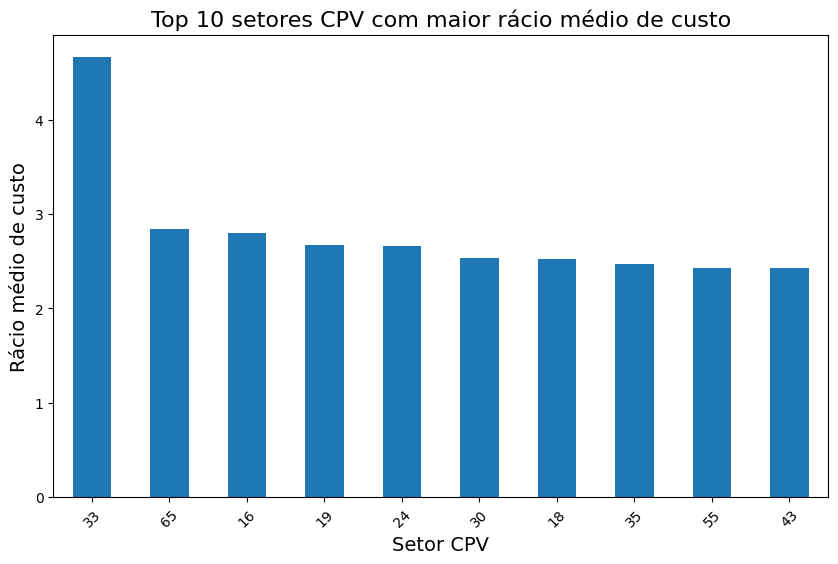

In [27]:
plt.figure(figsize=(10,6))

df_cpv_custo = (
    df.dropna(subset=["ratio_custo", "setor_cpv"])
      .groupby("setor_cpv")["ratio_custo"]
      .mean()
      .sort_values(ascending=False)
)

# top 10 CPVs com maior rácio médio
df_cpv_custo.head(10).plot(kind="bar")

plt.title("Top 10 setores CPV com maior rácio médio de custo", fontsize=16)
plt.xlabel("Setor CPV", fontsize=14)
plt.ylabel("Rácio médio de custo", fontsize=14)

plt.xticks(rotation=45)
plt.show()

In [28]:
cpvs_top = ['33','65','30','35','16','55','24','85','18','19']

for cpv in cpvs_top:
    exemplo = df[df["setor_cpv"] == cpv]["CPV"].dropna().iloc[0]
    print(f"{cpv} -> {exemplo}")

33 -> 33600000-6 - Produtos farmacêuticos
65 -> 65000000-3 - Serviços públicos
30 -> 30192000-1 - Material de escritório
35 -> 35125100-7 - Sensores
16 -> 16700000-2 - Tractores
55 -> 55524000-9 - Serviços de fornecimento de refeições (catering) a escolas
24 -> 24951120-2 - Lubrificante à base de silicone
85 -> 85121270-6 - Serviços de psiquiatria ou psicologia
18 -> 18143000-3 - Equipamento (vestuário) de protecção
19 -> 19200000-8 - Tecidos têxteis e artigos afins


## 8.3.3 Contratos por ajuste direto


In [29]:
#cálculo do rácio de ajustes diretos relativamente ao total de contratos de cada empresa
if {"adjudicatarios", "tipoprocedimento", "idcontrato"}.issubset(df.columns):
    df_adj = (
        df.dropna(subset=["adjudicatarios"])
          .groupby("adjudicatarios")
          .agg(
              total_contratos=("idcontrato", "count"),
              ajustes_diretos=(
                  "tipoprocedimento",
                  lambda x: (x == "Ajuste Direto Regime Geral").sum()
              )
          )
          .reset_index()
          .rename(columns={"adjudicatarios": "empresa"})
    )

    df_empresas = df_empresas.merge(df_adj, on="empresa", how="left")
    df_empresas[["total_contratos", "ajustes_diretos"]] = (
        df_empresas[["total_contratos", "ajustes_diretos"]].fillna(0)
    )

    df_empresas["ratio_ajuste"] = np.where(
        df_empresas["total_contratos"] > 0,
        df_empresas["ajustes_diretos"] / df_empresas["total_contratos"],
        0
    )

    n = len(df_empresas)
    pos_volume = df_empresas["ajustes_diretos"].rank(method="dense", ascending=False)
    pos_ratio = df_empresas["ratio_ajuste"].rank(method="dense", ascending=False)

    if n > 1:
        df_empresas["rating_volume"] = (n - pos_volume) / (n - 1)
        df_empresas["rating_ratio"] = (n - pos_ratio) / (n - 1)
    else:
        df_empresas["rating_volume"] = 0
        df_empresas["rating_ratio"] = 0

    df_empresas["score_ajuste_direto"] = (
        0.5 * df_empresas["rating_volume"] +
        0.5 * df_empresas["rating_ratio"]
    )

    display(
        df_empresas[
            ["empresa", "ajustes_diretos", "ratio_ajuste", "score_ajuste_direto"]
        ]
        .sort_values("score_ajuste_direto", ascending=False)
        .head(20)
    )
else:
    print("Faltam colunas necessárias para calcular ajustes diretos.")
    df_empresas["total_contratos"] = 0
    df_empresas["ajustes_diretos"] = 0
    df_empresas["ratio_ajuste"] = 0
    df_empresas["score_ajuste_direto"] = 0

,empresa,ajustes_diretos,ratio_ajuste,score_ajuste_direto
532,"501378669, AIRC ASSOCIACAO INFORMATICA DA REGI...",1813.0,0.978413,0.999761
85055,"514058242, REUMAMAIA MATERIAL ORTOPEDICO HOSPI...",921.0,0.992457,0.999715
1506,"503123226, CONTROLAUTO CONTROLO TECNICO AUTOMOVEL",868.0,0.990868,0.999686
95775,"505081849, ORTOMEDIFAR",713.0,1.000000,0.999622
71102,"980554802, SERVYTRONIX",569.0,1.000000,0.999514
4766,"506734579, SONS EM TRANSITO ESPETACULOS CULTURAIS",856.0,0.966140,0.999438
267,"504990926, MEDIDATA NET SISTEMAS DE INFORMACAO...",1119.0,0.950722,0.999377
662,"505141019, VORTAL COMERCIO ELETRONICO CONSULTA...",645.0,0.972851,0.999374
10657,"508963150, HOSPITAL CUF PORTO",493.0,0.976238,0.999269
72337,MIGUEL LUIS TEIXEIRA GUEDES,368.0,0.997290,0.999269


In [30]:
top_ajuste_filtrado = df_empresas[df_empresas["total_contratos"] >= 10][
    ["empresa", "total_contratos", "ajustes_diretos", "ratio_ajuste", "score_ajuste_direto"]
].sort_values("score_ajuste_direto", ascending=False)

display(top_ajuste_filtrado.head(20))

,empresa,total_contratos,ajustes_diretos,ratio_ajuste,score_ajuste_direto
532,"501378669, AIRC ASSOCIACAO INFORMATICA DA REGI...",1853.0,1813.0,0.978413,0.999761
85055,"514058242, REUMAMAIA MATERIAL ORTOPEDICO HOSPI...",928.0,921.0,0.992457,0.999715
1506,"503123226, CONTROLAUTO CONTROLO TECNICO AUTOMOVEL",876.0,868.0,0.990868,0.999686
95775,"505081849, ORTOMEDIFAR",713.0,713.0,1.000000,0.999622
71102,"980554802, SERVYTRONIX",569.0,569.0,1.000000,0.999514
4766,"506734579, SONS EM TRANSITO ESPETACULOS CULTURAIS",886.0,856.0,0.966140,0.999438
267,"504990926, MEDIDATA NET SISTEMAS DE INFORMACAO...",1177.0,1119.0,0.950722,0.999377
662,"505141019, VORTAL COMERCIO ELETRONICO CONSULTA...",663.0,645.0,0.972851,0.999374
10657,"508963150, HOSPITAL CUF PORTO",505.0,493.0,0.976238,0.999269
72337,MIGUEL LUIS TEIXEIRA GUEDES,369.0,368.0,0.997290,0.999269


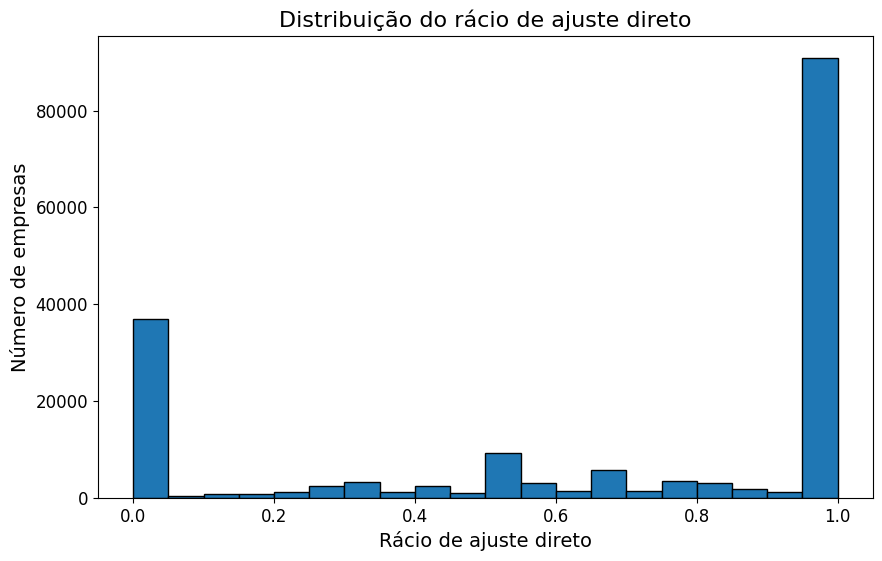

In [31]:
plt.figure(figsize=(10,6))

plt.hist(
    df_empresas["ratio_ajuste"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição do rácio de ajuste direto", fontsize=16)
plt.xlabel("Rácio de ajuste direto", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

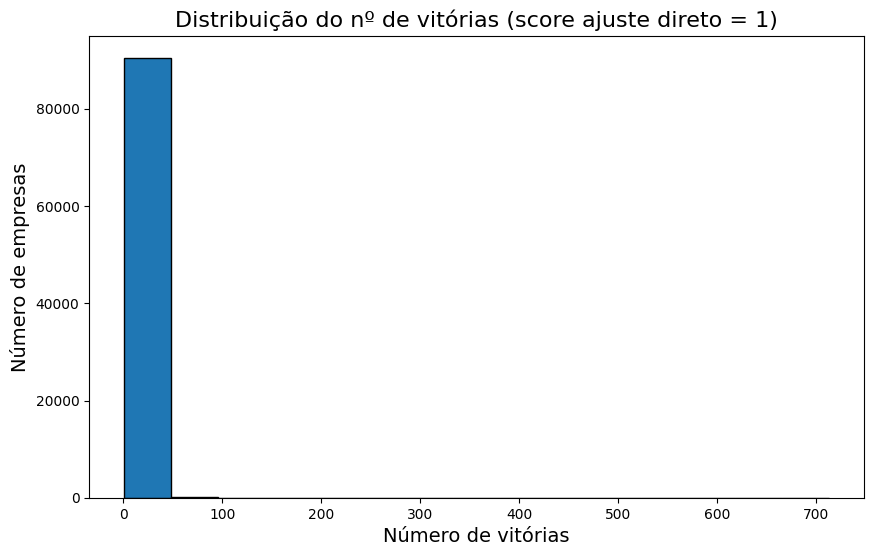

In [32]:
empresas_score1_ajuste = df_empresas[
    df_empresas["ratio_ajuste"] == 1
]

plt.figure(figsize=(10,6))

plt.hist(
    empresas_score1_ajuste["total_contratos"].dropna(),
    bins=15,
    edgecolor="black"
)

plt.title("Distribuição do nº de vitórias (score ajuste direto = 1)", fontsize=16)
plt.xlabel("Número de vitórias", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.show()

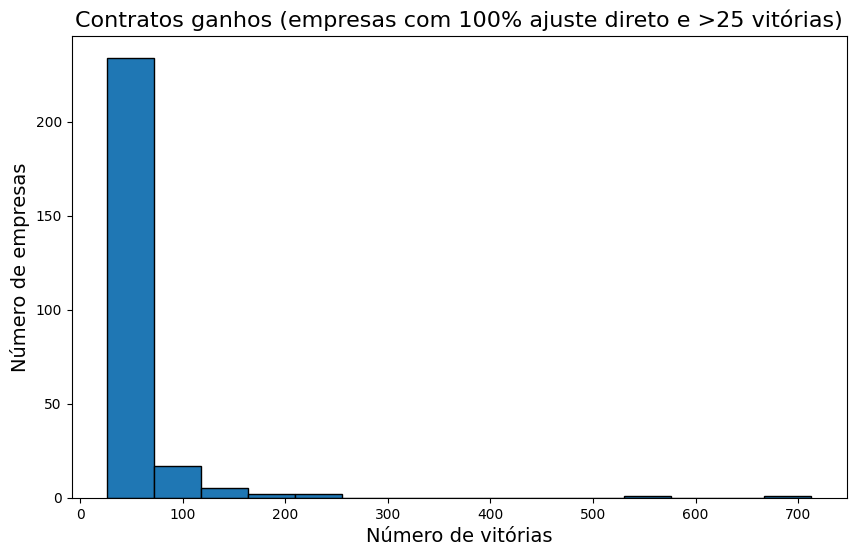

In [33]:
empresas_ajuste_puro = df_empresas[
    (df_empresas["ratio_ajuste"] == 1) &
    (df_empresas["total_contratos"] > 25)
]

plt.figure(figsize=(10,6))

plt.hist(
    empresas_ajuste_puro["total_contratos"].dropna(),
    bins=15,
    edgecolor="black"
)

plt.title("Contratos ganhos (empresas com 100% ajuste direto e >25 vitórias)", fontsize=16)
plt.xlabel("Número de vitórias", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.show()

In [34]:
# total de ajustes diretos no dataset inteiro
total_ajustes_df = (
    (df["tipoprocedimento"] == "Ajuste Direto Regime Geral")
    .sum()
)

# top 10 empresas
top10_ajuste_puro = (
    empresas_ajuste_puro
    .sort_values("total_contratos", ascending=False)
    .head(10)
    .copy()
)

# percentagem do total de ajustes diretos
top10_ajuste_puro["percentagem_total_ajustes"] = (
    top10_ajuste_puro["ajustes_diretos"] /
    total_ajustes_df
) * 100

# tabela final
display(
    top10_ajuste_puro[
        [
            "empresa",
            "total_contratos",
            "ajustes_diretos",
            "ratio_ajuste",
            "total_participacoes",
            "percentagem_total_ajustes"
        ]
    ]
)

,empresa,total_contratos,ajustes_diretos,ratio_ajuste,total_participacoes,percentagem_total_ajustes
95775,"505081849, ORTOMEDIFAR",713.0,713.0,1.0,713.0,0.071279
71102,"980554802, SERVYTRONIX",569.0,569.0,1.0,569.0,0.056883
4462,"503144851, CIMA CENTOR DE INSPECCOES MECANICAS...",237.0,237.0,1.0,238.0,0.023693
31602,LEONARDO MW LTD,219.0,219.0,1.0,219.0,0.021893
16696,MARIO PAULO MOURA SILVA FERREIRA,175.0,175.0,1.0,175.0,0.017495
9748,"509736289, JOAQUIM BARREIROS",165.0,165.0,1.0,165.0,0.016495
72441,"506123243, INSTITUTO CUF DIAGNOSTICO E TRATAMENTO",147.0,147.0,1.0,147.0,0.014696
15790,"504246240, MAXFIT REPRESENTACOES",142.0,142.0,1.0,142.0,0.014196
9903,"510969496, EQUIMETTO",122.0,122.0,1.0,122.0,0.012196
124821,"516710796, FARMACIA VCI HELDER CORR DE OLIVEIR...",120.0,120.0,1.0,120.0,0.011996


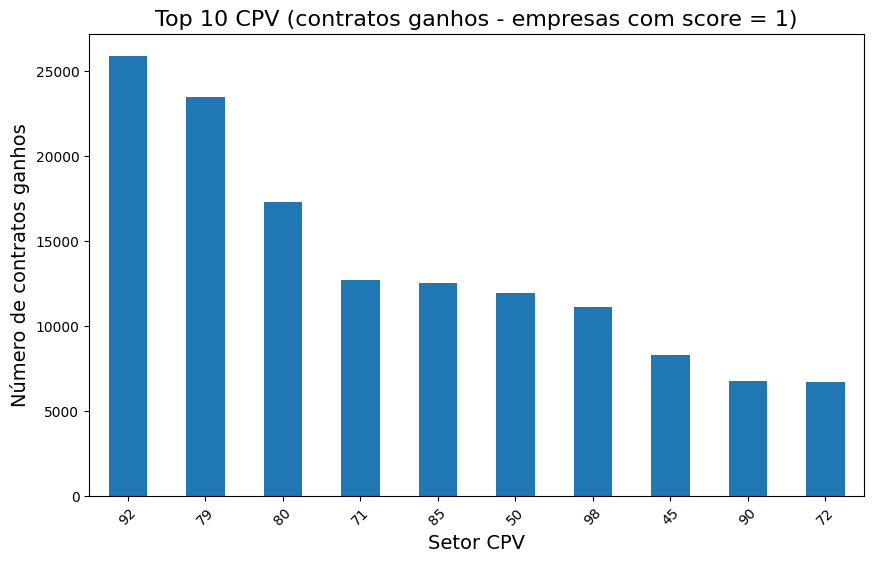

In [35]:

#Empresas com score = 1

lista_empresas = df_empresas[
    df_empresas["ratio_ajuste"] == 1
]["empresa"].unique()

# Filtrar contratos ganhos por estas empresas

df_adj = (
    df[df["adjudicatarios"].notna()]
    .assign(empresa=lambda x: x["adjudicatarios"].str.split("\n"))
    .explode("empresa")
)

df_adj["empresa"] = df_adj["empresa"].str.strip()

df_suspeitos_adj = df_adj[
    df_adj["empresa"].isin(lista_empresas)
]

#Distribuição por CPV
plt.figure(figsize=(10,6))

df_suspeitos_adj["setor_cpv"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 CPV (contratos ganhos - empresas com score = 1)", fontsize=16)
plt.xlabel("Setor CPV", fontsize=14)
plt.ylabel("Número de contratos ganhos", fontsize=14)

plt.xticks(rotation=45)
plt.show()

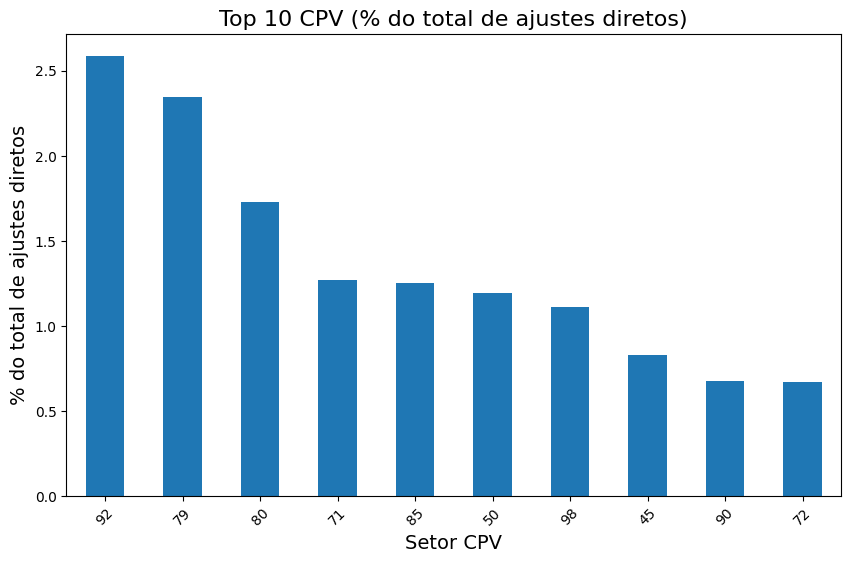

In [36]:
# Empresas com ratio_ajuste = 1

lista_empresas = df_empresas[
    df_empresas["ratio_ajuste"] == 1
]["empresa"].unique()

# Filtrar contratos ganhos por estas empresas

df_adj = (
    df[df["adjudicatarios"].notna()]
    .assign(empresa=lambda x: x["adjudicatarios"].str.split("\n"))
    .explode("empresa")
)

df_adj["empresa"] = df_adj["empresa"].str.strip()

df_suspeitos_adj = df_adj[
    df_adj["empresa"].isin(lista_empresas)
]

# total de ajustes diretos no dataset inteiro
total_ajustes = (
    df[df["tipoprocedimento"] == "Ajuste Direto Regime Geral"]
    ["idcontrato"]
    .count()
)

# contratos por CPV
cpv_counts = (
    df_suspeitos_adj["setor_cpv"]
    .value_counts()
    .head(10)
)

# percentagem do total de ajustes diretos
cpv_percent = (
    cpv_counts / total_ajustes
) * 100

# gráfico
plt.figure(figsize=(10,6))

cpv_percent.plot(kind="bar")

plt.title(
    "Top 10 CPV (% do total de ajustes diretos)",
    fontsize=16
)

plt.xlabel("Setor CPV", fontsize=14)
plt.ylabel("% do total de ajustes diretos", fontsize=14)

plt.xticks(rotation=45)

plt.show()

In [37]:
# CPVs que apareceram no gráfico (top 10)
top_cpv_codigos = df_suspeitos_adj["setor_cpv"].value_counts().head(10).index.tolist()


# extrair descrição mais representativa de cada CPV
cpv_descricoes = (
    df[df["setor_cpv"].isin(top_cpv_codigos)]
    .dropna(subset=["CPV"])
    .assign(descricao=lambda x: x["CPV"].str.split(" - ").str[1])
    .groupby("setor_cpv")["descricao"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .sort_values("setor_cpv")
)

display(cpv_descricoes)

,setor_cpv,descricao
0,45,Construção
1,50,Serviços de reparação e manutenção
2,71,"Serviços de arquitectura, construção, engenhar..."
3,72,"Serviços de TI: consultoria, desenvolvimento d..."
4,79,"Serviços a empresas: direito, comercialização,..."
5,80,Serviços de ensino e formação
6,85,Serviços de saúde e acção social
7,90,Serviços de limpeza
8,92,"Serviços recreativos, culturais e desportivos"
9,98,Serviços diversos


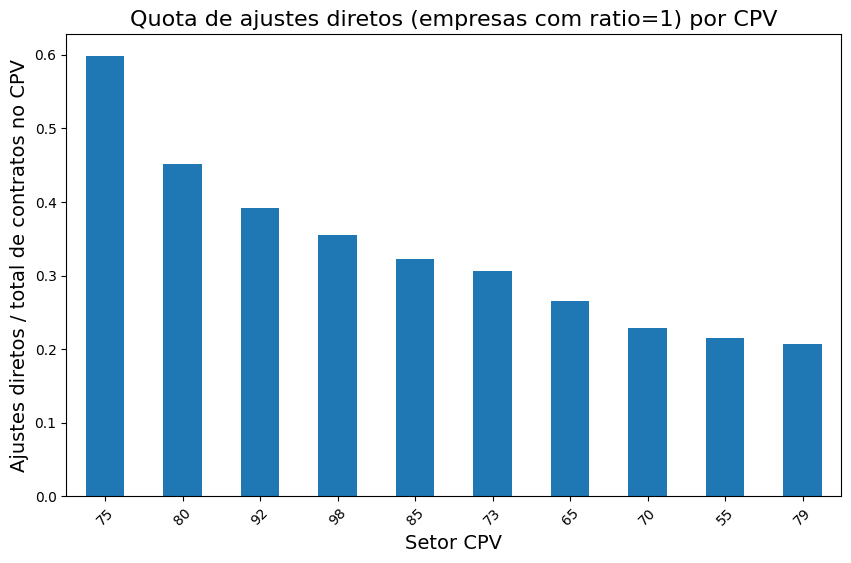

In [38]:

#Empresas com ratio_ajuste = 1
empresas_ajuste1 = df_empresas[
    df_empresas["ratio_ajuste"] == 1
]["empresa"].unique()

# Filtrar apenas ajustes diretos ganhos por essas empresas
df_ajuste1 = df[
    (df["adjudicatarios"].isin(empresas_ajuste1)) &
    (df["tipoprocedimento"] == "Ajuste Direto Regime Geral")
]

#Contagem de ajustes diretos por CPV
ajustes_cpv = df_ajuste1["setor_cpv"].value_counts()

#total de contratos por CPV
total_cpv = df["setor_cpv"].value_counts()

#Rácio final
ratio_cpv = (ajustes_cpv / total_cpv).dropna()

#plot
plt.figure(figsize=(10,6))

ratio_cpv.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Quota de ajustes diretos (empresas com ratio=1) por CPV", fontsize=16)
plt.xlabel("Setor CPV", fontsize=14)
plt.ylabel("Ajustes diretos / total de contratos no CPV", fontsize=14)

plt.xticks(rotation=45)
plt.show()

In [39]:
# descrição CPV
df["cpv_desc"] = df["CPV"].astype(str).str.split(" - ").str[1]

# mapa CPV -> descrição
cpv_map = (
    df.groupby("setor_cpv")["cpv_desc"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
)

# transformar série em dataframe
df_ratio_cpv = ratio_cpv.reset_index()
df_ratio_cpv.columns = ["setor_cpv", "ratio"]

# juntar descrição
df_ratio_cpv = df_ratio_cpv.merge(
    cpv_map,
    on="setor_cpv",
    how="left"
)

# top 10
display(
    df_ratio_cpv
    .sort_values("ratio", ascending=False)
    .head(10)
)

,setor_cpv,ratio,cpv_desc
36,75,0.598028,Serviços relacionados com a administração pública
40,80,0.451152,Serviços de ensino e formação
43,92,0.392442,"Serviços recreativos, culturais e desportivos"
44,98,0.354975,Serviços diversos
41,85,0.322504,Serviços de saúde e acção social
35,73,0.305965,Serviços de investigação e desenvolvimento e s...
30,65,0.265869,Serviços públicos
32,70,0.228696,Serviços de arrendamento ou locação de bens im...
26,55,0.215492,Serviços de fornecimento de refeições (catering)
39,79,0.206840,"Serviços a empresas: direito, comercialização,..."


,adjudicante,n_contratos,percentagem_total_ajustes
0,"500051070, MUNICIPIO DE LISBOA",4098,0.409678
1,"509906478, CENTRO DE FORMACAO PROFISSIONAL DA ...",3377,0.337600
2,"501442600, INSTITUTO DO EMPREGO E FORMACAO PRO...",3040,0.303910
3,"600012662, MINISTERIO DA DEFESA NACIONAL MARINHA",2574,0.257324
4,"506362299, INSTITUTO PORTUGUES DE ONCOLOGIA DO...",2562,0.256124
5,"508338476, CENTRO HOSPITALAR PSIQUIATRICO DE L...",2454,0.245327
6,"501886354, CENCAL CENTRO DE FORMACAO PROFISSIO...",2018,0.201740
7,"502098139, MUNICIPIO DE LOULE",1634,0.163351
8,"500122237, FUNDACAO INATEL",1552,0.155154
9,"503584215, EGEAC EMPRESA DE GESTAO DE EQUIPAME...",1233,0.123263


<Figure size 1000x600 with 0 Axes>

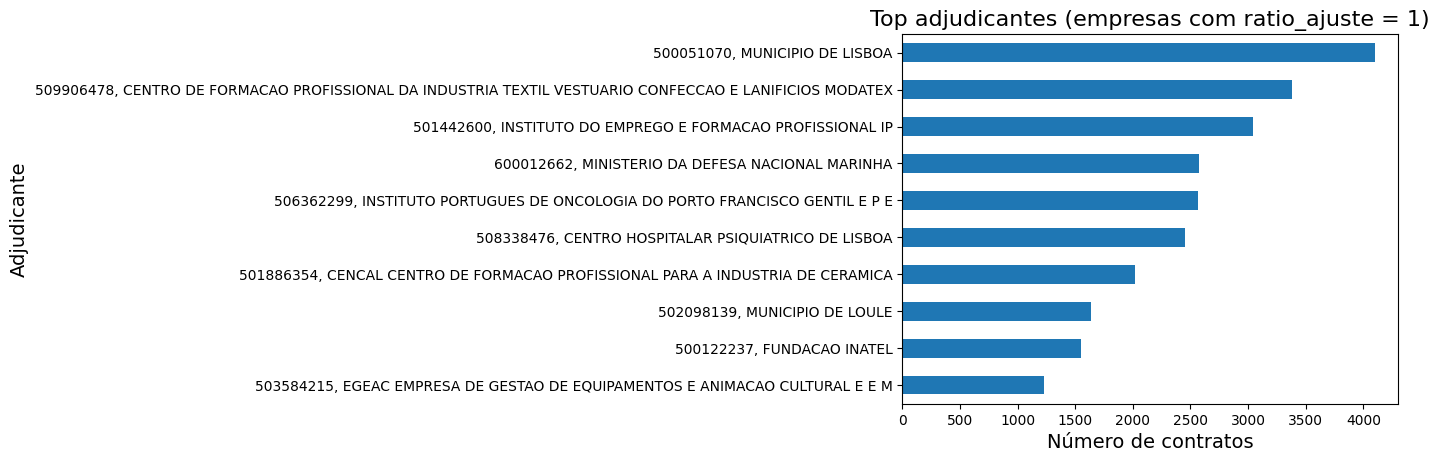

In [40]:
# Empresas com ratio_ajuste = 1
empresas_ajuste1 = df_empresas[
    df_empresas["ratio_ajuste"] == 1
]["empresa"].unique()

# Filtrar contratos dessas empresas
df_ajuste1 = df[
    df["adjudicatarios"].isin(empresas_ajuste1)
]

# total de ajustes diretos no dataset inteiro
total_ajustes = (
    df[df["tipoprocedimento"] == "Ajuste Direto Regime Geral"]
    ["idcontrato"]
    .count()
)

# tabela adjudicantes
top_adjudicantes = (
    df_ajuste1["adjudicante"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_adjudicantes.columns = [
    "adjudicante",
    "n_contratos"
]

# percentagem do total de ajustes diretos
top_adjudicantes["percentagem_total_ajustes"] = (
    top_adjudicantes["n_contratos"] / total_ajustes
) * 100

# mostrar tabela
display(top_adjudicantes)

# gráfico
plt.figure(figsize=(10,6))

top_adjudicantes.sort_values("n_contratos").plot(
    kind="barh",
    x="adjudicante",
    y="n_contratos",
    legend=False
)

plt.title(
    "Top adjudicantes (empresas com ratio_ajuste = 1)",
    fontsize=16
)

plt.xlabel("Número de contratos", fontsize=14)
plt.ylabel("Adjudicante", fontsize=14)

plt.show()

In [41]:
# Empresas com ratio_ajuste = 1
empresas_ajuste1 = df_empresas[
    df_empresas["ratio_ajuste"] == 1
]["empresa"].unique()

# Filtrar contratos
df_filtrado = df[
    df["adjudicatarios"].isin(empresas_ajuste1)
].copy()

df_filtrado["empresa_clean"] = (
    df_filtrado["adjudicatarios"]
    .str.replace(r"^\d+,\s*", "", regex=True)
    .str.strip()
)

total_precos = df[
    df["tipoprocedimento"] == "Ajuste Direto Regime Geral"
]["precoContratual"].sum()

# Somar valores
valor_total = (
    df_filtrado
    .groupby("empresa_clean")["precoContratual"]
    .sum()
    .sort_values(ascending=False)
)

# juntar manualmente VARIAN
if (
    "VARIAN MEDICAL SYSTEMS IBERICA" in valor_total.index and
    "VARIAN MEDICAL SYSTEMS IBERICA EM PORTUGAL" in valor_total.index
):
    valor_total.loc["VARIAN MEDICAL SYSTEMS IBERICA"] += valor_total.loc[
        "VARIAN MEDICAL SYSTEMS IBERICA EM PORTUGAL"
    ]

    valor_total = valor_total.drop(
        "VARIAN MEDICAL SYSTEMS IBERICA EM PORTUGAL"
    )

# transformar em dataframe
valor_total = valor_total.reset_index()

valor_total.columns = [
    "empresa",
    "valor_total_contratos"
]

# percentagem do total de preços contratuais
valor_total["percentagem_total_precos"] = (
    valor_total["valor_total_contratos"] / total_precos
) * 100

# top 10
valor_total = (
    valor_total
    .sort_values("valor_total_contratos", ascending=False)
    .head(10)
)

display(valor_total)

,empresa,valor_total_contratos,percentagem_total_precos
7,VARIAN MEDICAL SYSTEMS IBERICA,20353141.39,0.093295
0,LEONARDO MW LTD,9626552.16,0.044126
1,UNISYS U,9355500.00,0.042884
2,HARSCO RAIL EUROPE GMBH,7994137.00,0.036644
3,BMC SOFTWARE DISTRIBUITION BV,7405490.30,0.033945
4,AMBULANCIAS CRESPO,7081350.25,0.032460
5,GEMALTO,6758500.00,0.030980
6,ASSOCIACAO DE TURISMO DO PORTO,6657901.45,0.030519
8,SVEP SEGURANCA E VIGILANCIA DE PESSOAL,5609570.50,0.025713
9,JOAO MIGUEL GORJAO HENRIQUES DE BRITO,5550000.00,0.025440


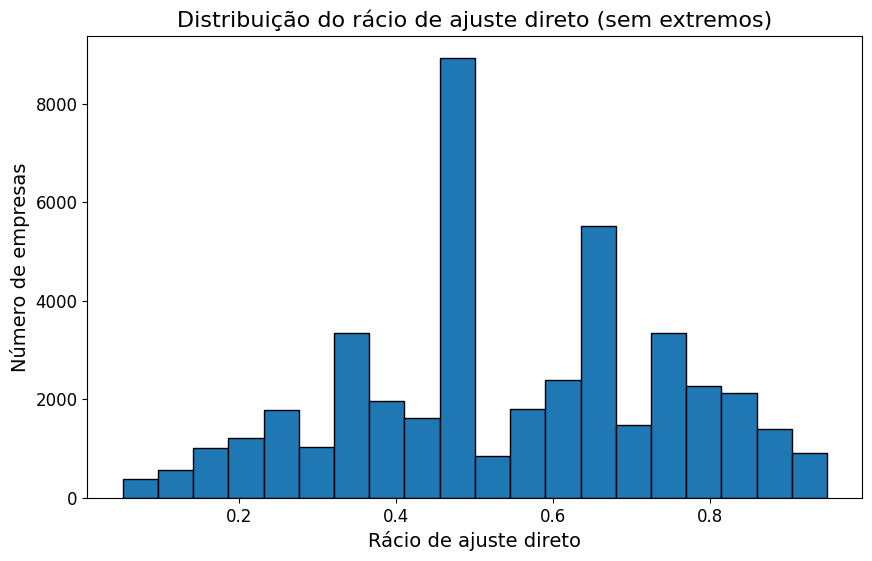

In [42]:
# remover extremos fixos
df_filtrado = df_empresas[
    (df_empresas["ratio_ajuste"] > 0.05) &
    (df_empresas["ratio_ajuste"] < 0.95)
]

plt.figure(figsize=(10,6))

plt.hist(
    df_filtrado["ratio_ajuste"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição do rácio de ajuste direto (sem extremos)", fontsize=16)
plt.xlabel("Rácio de ajuste direto", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

## 8.3.4 Elevada taxa de adjudicação



In [43]:
df_empresas["score_taxa_adjudicacao"] = np.where(
    df_empresas["total_participacoes"] > 0,
    df_empresas["total_adjudicatario"] / df_empresas["total_participacoes"],
    0
)

display(
    df_empresas[
        ["empresa", "total_adjudicatario", "total_participacoes", "score_taxa_adjudicacao"]
    ]
    .sort_values("score_taxa_adjudicacao", ascending=False)
    .head(20)
)

,empresa,total_adjudicatario,total_participacoes,score_taxa_adjudicacao
160423,DAIANE DE ARAUJO ASSIS DOS SANTOS,1.0,1.0,1.0
160422,"515709689, SALPICOS DOUTONO JARDINS",1.0,1.0,1.0
160421,ANTONIO JOSE A FERREIRA,1.0,1.0,1.0
160420,"515294381, CARLA ALEXANDRA FERREIRA SILVA SOCI...",1.0,1.0,1.0
160419,"516872354, IDEIAS100PAUSA",1.0,1.0,1.0
160418,JOAO MANUEL MACHADO MARTINS,1.0,1.0,1.0
160417,MARIANA NETO PIRES,1.0,1.0,1.0
16,"506229580, OLIMPIA & FILHOS",2.0,2.0,1.0
160415,"507887409, MINERALIA",1.0,1.0,1.0
160414,LUCILIA MARIA RODRIGUES MONTEIRO,1.0,1.0,1.0


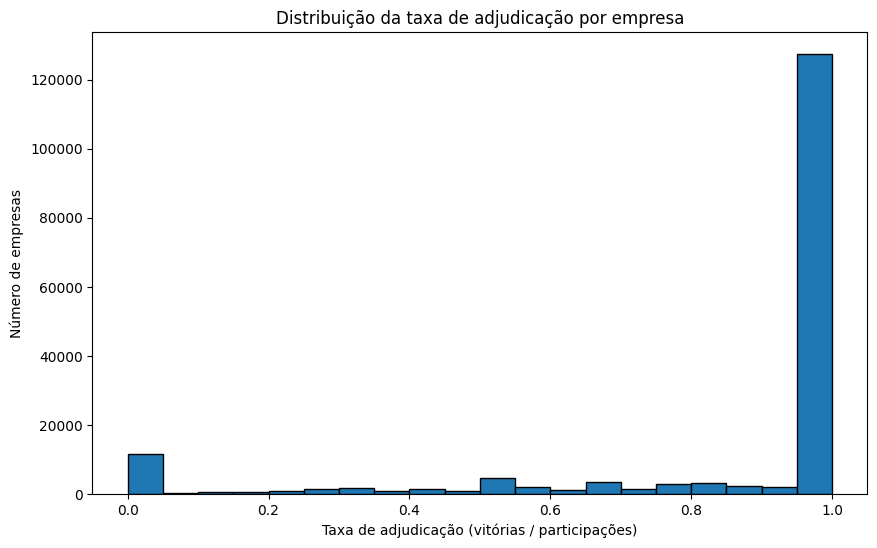

In [44]:
plt.figure(figsize=(10,6))

plt.hist(
    df_empresas["score_taxa_adjudicacao"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição da taxa de adjudicação por empresa")
plt.xlabel("Taxa de adjudicação (vitórias / participações)")
plt.ylabel("Número de empresas")

plt.show()

In [45]:
#Filtrar empresa com score 1
df_score1 = df_empresas[
    df_empresas["score_taxa_adjudicacao"] == 1
]

#ordenar por número de participações
top_empresas = (
    df_score1[
        ["empresa", "total_participacoes", "total_adjudicatario"]
    ]
    .sort_values("total_participacoes", ascending=False)
    .head(10)
)

display(top_empresas)

,empresa,total_participacoes,total_adjudicatario
85055,"514058242, REUMAMAIA MATERIAL ORTOPEDICO HOSPI...",928.0,928.0
1506,"503123226, CONTROLAUTO CONTROLO TECNICO AUTOMOVEL",876.0,876.0
95775,"505081849, ORTOMEDIFAR",713.0,713.0
19134,MARIO PAULO FERREIRA,647.0,647.0
71102,"980554802, SERVYTRONIX",569.0,569.0
84214,CEPHEID IBERIA U EM PORTUGAL,370.0,370.0
72337,MIGUEL LUIS TEIXEIRA GUEDES,369.0,369.0
28601,"513646442, PG BOOKING AGENCIAMENTO E PRODUCAO ...",365.0,365.0
60484,"505542005, FARMACIA ELVAS",287.0,287.0
329,"503526568, FRESOFT SOLUCOES INFORMATICAS",280.0,280.0


In [46]:

#Empresas com score_taxa_adjudicacao = 1
empresas_score1 = df_empresas[
    df_empresas["score_taxa_adjudicacao"] == 1
]["empresa"].unique()

#Filtrar contratos ganhos
df_filtrado = df[
    df["adjudicatarios"].isin(empresas_score1)
]

#Somar valores por empresa
valor_total = (
    df_filtrado
    .groupby("adjudicatarios")["precoContratual"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(valor_total)

adjudicatarios
ENDESA ENERGIA PORTUGAL                                                          1.033904e+08
980861896, GULF MED AVIATION SERVICES LIMITED EM PORTUGAL                        7.747516e+07
513481613, VERTEX PHARMACEUTICALS PORTUGAL UNIPESSOA                             7.439644e+07
504569759, SAP PORTUGAL SISTEMAS APLICACOES E PRODUTOS INFORMATICOS SOCIEDADE    4.368978e+07
507632796, SANOFI PASTEUR MSD                                                    2.385226e+07
CEPHEID IBERIA U EM PORTUGAL                                                     2.339040e+07
500274371, BOMBARDIER TRANSPORTATION PORT                                        2.318430e+07
501404198, JANSSEN CILAG FARMACEUTICA LD                                         1.814228e+07
ARCELORMITTAL ESPANA                                                             1.756794e+07
CARTONAJES UNION                                                                 1.644451e+07
Name: precoContratual, dtype: float64

,setor_cpv,n_empresas,percentagem_total_empresas
0,79,19259,12.005062
1,92,16112,10.043385
2,80,13124,8.180821
3,71,11017,6.867426
4,98,10479,6.532065
5,85,10331,6.439810
6,50,8357,5.209320
7,45,6052,3.772503
8,75,5589,3.483893
9,90,5560,3.465816


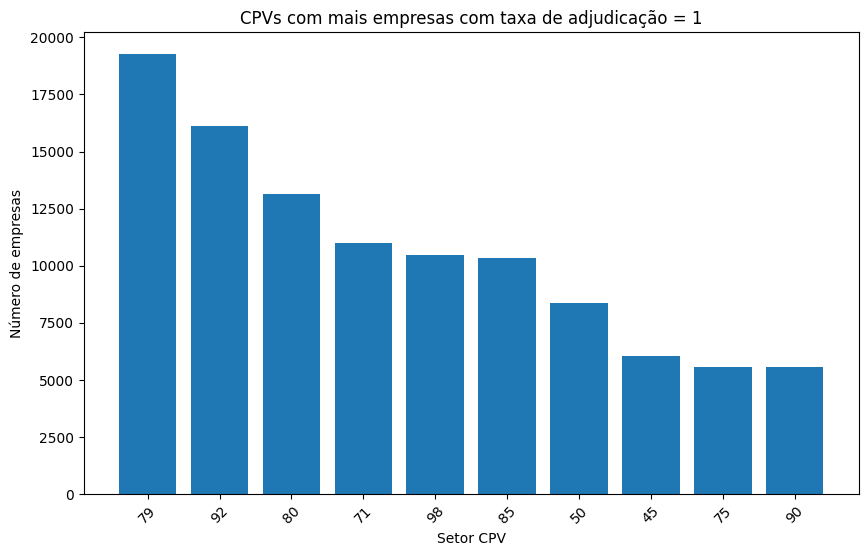

In [47]:
# empresas com score_taxa_adjudicacao = 1
empresas_score1 = df_empresas[
    df_empresas["score_taxa_adjudicacao"] == 1
]["empresa"].unique()

# filtrar contratos dessas empresas
df_score1 = df[
    df["adjudicatarios"].isin(empresas_score1)
].copy()

# contar CPVs por empresa (sem duplicar)
df_unique = df_score1.drop_duplicates(
    subset=["adjudicatarios", "setor_cpv"]
)

cpv_counts = (
    df_unique["setor_cpv"]
    .value_counts()
    .reset_index()
)

cpv_counts.columns = [
    "setor_cpv",
    "n_empresas"
]

# total de empresas na base de dados
total_empresas = (
    df["adjudicatarios"]
    .nunique()
)

# percentagem do total de empresas
cpv_counts["percentagem_total_empresas"] = (
    cpv_counts["n_empresas"] / total_empresas
) * 100

display(cpv_counts.head(10))

# gráfico
plt.figure(figsize=(10,6))

plt.bar(
    cpv_counts["setor_cpv"].head(10),
    cpv_counts["n_empresas"].head(10)
)

plt.title(
    "CPVs com mais empresas com taxa de adjudicação = 1"
)

plt.xlabel("Setor CPV")
plt.ylabel("Número de empresas")

plt.xticks(rotation=45)

plt.show()

## 8.3.5 Picos de contratos no final do ano


In [48]:
#rácio de contratos em novembro/dezembro de cada empresa
if {"adjudicatarios", "idcontrato", "mes"}.issubset(df.columns):
    contratos_empresa = (
        df.dropna(subset=["adjudicatarios"])
          .groupby("adjudicatarios")["idcontrato"]
          .count()
    )

    contratos_nov_dez = (
        df[df["mes"].isin([11, 12]) & df["adjudicatarios"].notna()]
        .groupby("adjudicatarios")["idcontrato"]
        .count()
    )

    df_empresas["contratos_totais_empresa"] = df_empresas["empresa"].map(contratos_empresa).fillna(0)
    df_empresas["contratos_nov_dez"] = df_empresas["empresa"].map(contratos_nov_dez).fillna(0)

    df_empresas["score_picos_fim_ano"] = np.where(
        df_empresas["contratos_totais_empresa"] > 0,
        df_empresas["contratos_nov_dez"] / df_empresas["contratos_totais_empresa"],
        0
    )

    display(
        df_empresas[
            ["empresa", "contratos_nov_dez", "contratos_totais_empresa", "score_picos_fim_ano"]
        ]
        .sort_values("score_picos_fim_ano", ascending=False)
        .head(20)
    )
else:
    print("Faltam colunas necessárias para calcular picos no final do ano.")
    df_empresas["contratos_totais_empresa"] = 0
    df_empresas["contratos_nov_dez"] = 0
    df_empresas["score_picos_fim_ano"] = 0

,empresa,contratos_nov_dez,contratos_totais_empresa,score_picos_fim_ano
25642,"509887287, VIANA NATACAO CLUBE",1.0,1.0,1.0
111175,"501410414, SOCIEDADE DE RECREIO UNIAO E PROGRE...",1.0,1.0,1.0
111176,PAULO ALEXANDRE RIBEIRO,1.0,1.0,1.0
160407,"507893816, SERRALHARIA VIDAL",1.0,1.0,1.0
111126,"513396322, ASSOCIACAO BEIRA AGUIEIRA DE APOIO ...",1.0,1.0,1.0
111127,"515209686, 3URA",1.0,1.0,1.0
111128,ORDET S R L,1.0,1.0,1.0
111135,SOBRITES HELDER AGOSTINHO TEIXEIRA PEREIRA,3.0,3.0,1.0
111140,"508048966, METALURGICA DA SEIXA",1.0,1.0,1.0
111141,MARTA SOFIA DA SILVA FERREIRA MONTEIRO,1.0,1.0,1.0


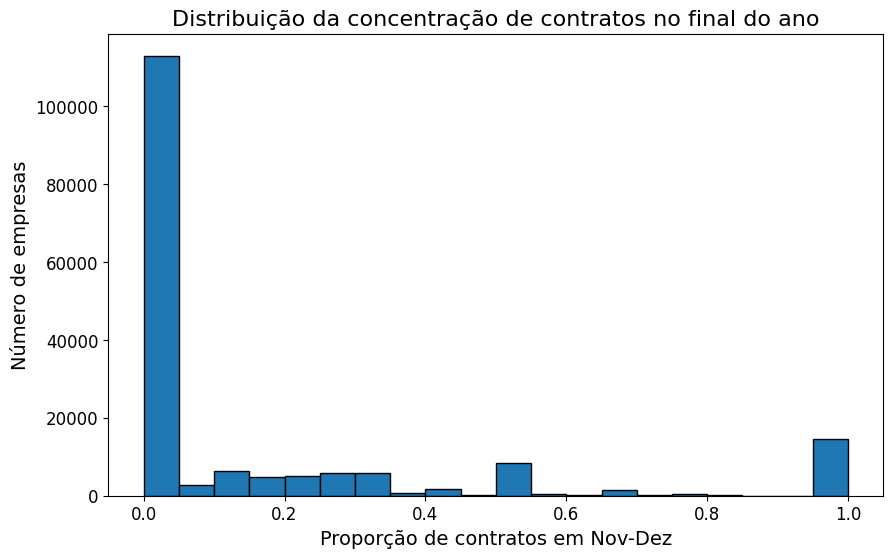

In [49]:
plt.figure(figsize=(10,6))

plt.hist(
    df_empresas["score_picos_fim_ano"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição da concentração de contratos no final do ano", fontsize=16)
plt.xlabel("Proporção de contratos em Nov-Dez", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

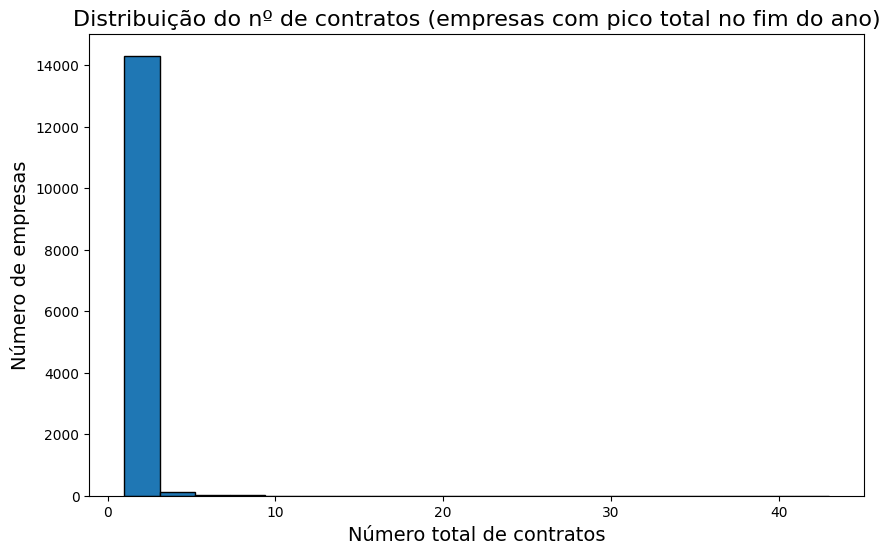

In [50]:
df_score1 = df_empresas[
    df_empresas["score_picos_fim_ano"] == 1
]

plt.figure(figsize=(10,6))

plt.hist(
    df_score1["contratos_totais_empresa"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição do nº de contratos (empresas com pico total no fim do ano)", fontsize=16)
plt.xlabel("Número total de contratos", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.show()

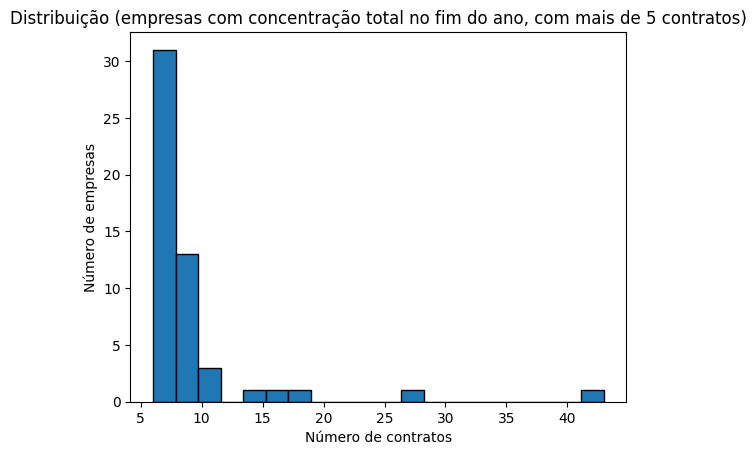

In [51]:
df_score1 = df_empresas[
    (df_empresas["score_picos_fim_ano"] == 1) &
    (df_empresas["contratos_totais_empresa"] > 5)
]

plt.hist(df_score1["contratos_totais_empresa"], bins=20, edgecolor="black")
plt.title("Distribuição (empresas com concentração total no fim do ano, com mais de 5 contratos)")
plt.xlabel("Número de contratos")
plt.ylabel("Número de empresas")
plt.show()

In [52]:
# empresas com score = 1
empresas_score1 = df_empresas[
    df_empresas["score_picos_fim_ano"] == 1
]

# top 10 por número total de contratos
top10_fim_ano = (
    empresas_score1
    .sort_values("contratos_totais_empresa", ascending=False)
    .head(10)
    .copy()
)

# total de contratos em Nov-Dez na base inteira
total_nov_dez = df[df["mes"].isin([11, 12])]["idcontrato"].count()

# percentagem que os contratos dessas empresas representam
top10_fim_ano["percentagem_nov_dez"] = (
    top10_fim_ano["contratos_nov_dez"] / total_nov_dez
) * 100

# tabela final
display(
    top10_fim_ano[
        [
            "empresa",
            "contratos_totais_empresa",
            "contratos_nov_dez",
            "percentagem_nov_dez"
        ]
    ]
)

,empresa,contratos_totais_empresa,contratos_nov_dez,percentagem_nov_dez
146815,AQUISICAO DE SERVICOS DE FORMACAO PROFISSIONAL,43.0,43.0,0.014527
75509,"512007373, CASA CHEIA",28.0,28.0,0.009460
21883,"510830013, CENARIOS INCRIVEIS",18.0,18.0,0.006081
61783,RUI MIGUEL PINTO DA SILVA,16.0,16.0,0.005406
147514,EURODIDATA MATERIAL DIDACTICO,15.0,15.0,0.005068
122532,KOMMAD PUBLICIDAD,10.0,10.0,0.003378
62010,VWR INTERNACIONAL,10.0,10.0,0.003378
37306,"513883827, ESTRELAS E PELICANOS ASSOCIACAO CUL...",10.0,10.0,0.003378
99456,"512023093, CLUBE NAVAL DA HORTA",9.0,9.0,0.003041
38381,PEDRO NUNO LEAL NABAIS NUNES,9.0,9.0,0.003041


In [53]:
# empresas com score = 1
lista_empresas = df_empresas[
    df_empresas["score_picos_fim_ano"] == 1
]["empresa"].unique()

# contratos dessas empresas
df_score1 = df[
    df["adjudicatarios"].isin(lista_empresas)
]

# total de contratos Nov-Dez na base inteira
total_nov_dez = df[df["mes"].isin([11,12])]["idcontrato"].count()

# adjudicantes mais comuns
top_adjudicantes = (
    df_score1.groupby("adjudicante")
    .agg(
        contratos_nov_dez=("idcontrato", "count")
    )
    .sort_values("contratos_nov_dez", ascending=False)
    .head(10)
)

# percentagem do total Nov-Dez
top_adjudicantes["percentagem_total_nov_dez"] = (
    top_adjudicantes["contratos_nov_dez"] / total_nov_dez
) * 100

display(top_adjudicantes)

,contratos_nov_dez,percentagem_total_nov_dez
adjudicante,,
"500051070, MUNICIPIO DE LISBOA",562,0.189870
"501442600, INSTITUTO DO EMPREGO E FORMACAO PROFISSIONAL IP",505,0.170613
"600012662, MINISTERIO DA DEFESA NACIONAL MARINHA",237,0.080070
"501617582, UNIVERSIDADE DE COIMBRA",202,0.068245
"501413197, UNIVERSIDADE DO PORTO",191,0.064529
"600084434, AGRUPAMENTO DE ESCOLAS DE ALPENDORADA",189,0.063853
"500122237, FUNDACAO INATEL",154,0.052028
"600015467, SECRETARIA GERAL DO MINISTERIO DA EDUCACAO E CIENCIA",141,0.047636
"509906478, CENTRO DE FORMACAO PROFISSIONAL DA INDUSTRIA TEXTIL VESTUARIO CONFECCAO E LANIFICIOS MODATEX",122,0.041217


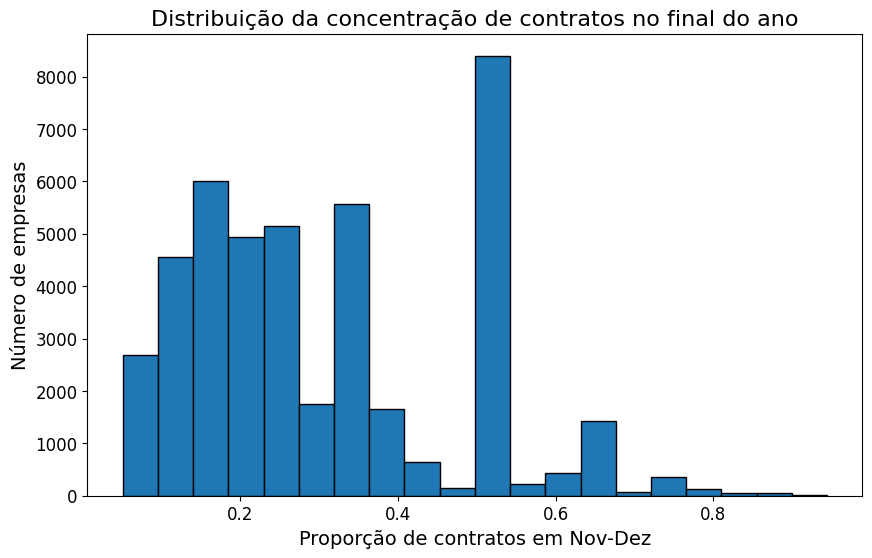

In [54]:
# remover extremos fixos
df_filtrado = df_empresas[
    (df_empresas["score_picos_fim_ano"] > 0.05) &
    (df_empresas["score_picos_fim_ano"] < 0.95)
]

plt.figure(figsize=(10,6))

plt.hist(
    df_filtrado["score_picos_fim_ano"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição da concentração de contratos no final do ano", fontsize=16)
plt.xlabel("Proporção de contratos em Nov-Dez", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

## 8.3.6 Picos de contratação em períodos eleitorais

In [55]:
#rácio de contratos durante periodos eleitorais (3 meses antes, e 3 depois)
risco_eleitoral_empresas = (
    df.groupby("adjudicatarios")
    .agg(
        total_contratos=("idcontrato", "nunique"),
        contratos_janela_eleitoral=("janela_eleicoes", lambda x: (x != "não").sum()),
        contratos_AR=("AR", lambda x: (x == "sim").sum()),
        contratos_AL=("AL", lambda x: (x == "sim").sum()),
        contratos_antes=("janela_eleicoes", lambda x: (x == "3 meses antes").sum()),
        contratos_depois=("janela_eleicoes", lambda x: (x == "3 meses depois").sum())
    )
    .reset_index()
)

risco_eleitoral_empresas["rating_eleitoral"] = (
    risco_eleitoral_empresas["contratos_janela_eleitoral"] /
    risco_eleitoral_empresas["total_contratos"]
)

risco_eleitoral_empresas["rating_AR"] = (
    risco_eleitoral_empresas["contratos_AR"] /
    risco_eleitoral_empresas["total_contratos"]
)

risco_eleitoral_empresas["rating_AL"] = (
    risco_eleitoral_empresas["contratos_AL"] /
    risco_eleitoral_empresas["total_contratos"]
)

risco_eleitoral_empresas["rating_antes"] = (
    risco_eleitoral_empresas["contratos_antes"] /
    risco_eleitoral_empresas["total_contratos"]
)

risco_eleitoral_empresas["rating_depois"] = (
    risco_eleitoral_empresas["contratos_depois"] /
    risco_eleitoral_empresas["total_contratos"]
)



risco_eleitoral_empresas = risco_eleitoral_empresas.sort_values(
    ["rating_eleitoral", "total_contratos"],
    ascending=[False, False]
)

risco_eleitoral_empresas.head(20)

,adjudicatarios,total_contratos,contratos_janela_eleitoral,contratos_AR,contratos_AL,contratos_antes,contratos_depois,rating_eleitoral,rating_AR,rating_AL,rating_antes,rating_depois
3820,"500965099, ORDEM DOS ADVOGADOS",40,40,40,0,0,40,1.0,1.000000,0.000000,0.000000,1.000000
77872,"517352729, NIVEL MAIUSCULO",22,22,0,22,22,0,1.0,0.000000,1.000000,1.000000,0.000000
79912,"518272192, TLCI ENERGIA",20,20,18,19,1,19,1.0,0.900000,0.950000,0.050000,0.950000
76734,"516954601, GEOCLIMA",18,18,18,0,1,17,1.0,1.000000,0.000000,0.055556,0.944444
106538,EURODIDACTA MATERIAL DIDACTICO,16,16,12,12,8,8,1.0,0.750000,0.750000,0.500000,0.500000
106543,EURODIDATA MATERIAL DIDACTICO,15,15,0,15,0,15,1.0,0.000000,1.000000,0.000000,1.000000
10413,"502352884, ASAS S MAMEDE DA VENTOSA",14,14,8,8,6,8,1.0,0.571429,0.571429,0.428571,0.571429
80195,"518462854, FERRAWORKS MATERIAIS DE CONSTRUCAO",14,14,10,5,6,8,1.0,0.714286,0.357143,0.428571,0.571429
4384,"501120840, ASSOC SOC DE A DOS CUNHADOS",13,13,9,7,7,6,1.0,0.692308,0.538462,0.538462,0.461538
115697,JAIME MANUEL FERNANDES PANCHA,13,13,9,8,5,8,1.0,0.692308,0.615385,0.384615,0.615385


In [56]:
(risco_eleitoral_empresas["rating_eleitoral"] == 1).sum()

np.int64(31655)

In [57]:
risco_eleitoral_empresas["rating_eleitoral"].describe()

count    160424.000000
mean          0.364601
std           0.378223
min           0.000000
25%           0.000000
50%           0.312500
75%           0.583333
max           1.000000
Name: rating_eleitoral, dtype: float64

In [58]:
risco_eleitoral_empresas = risco_eleitoral_empresas.sort_values(
    ["rating_eleitoral", "total_contratos"],
    ascending=[False, False]
)

df_empresas = df_empresas.merge(
    risco_eleitoral_empresas[["adjudicatarios", "rating_eleitoral"]]
    .rename(columns={
        "adjudicatarios": "empresa",
        "rating_eleitoral": "score_periodos_eleitorais"
    }),
    on="empresa",
    how="left"
)

df_empresas["score_periodos_eleitorais"] = (
    df_empresas["score_periodos_eleitorais"].fillna(0)
)

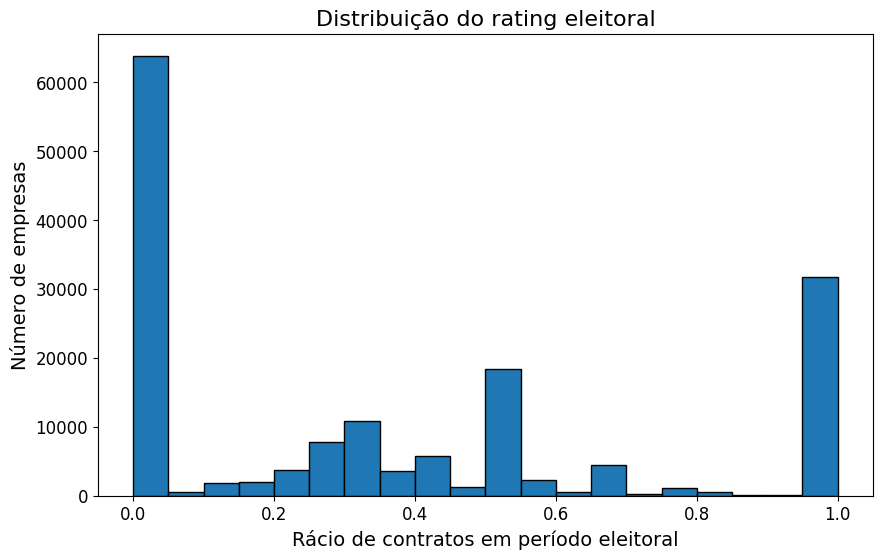

In [59]:
plt.figure(figsize=(10,6))

plt.hist(
    risco_eleitoral_empresas["rating_eleitoral"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição do rating eleitoral", fontsize=16)
plt.xlabel("Rácio de contratos em período eleitoral", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

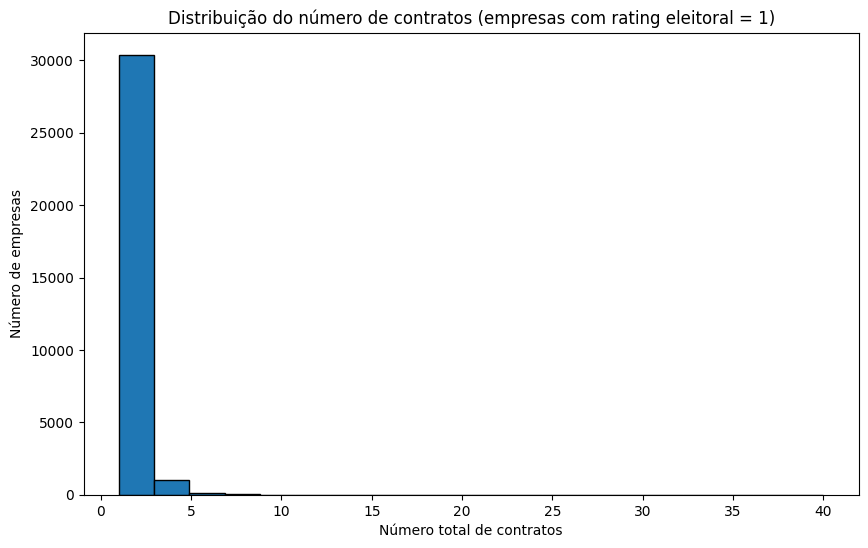

In [60]:
# empresas com score eleitoral = 1
df_score1 = risco_eleitoral_empresas[
    risco_eleitoral_empresas["rating_eleitoral"] == 1
]

# distribuição do número total de contratos
plt.figure(figsize=(10,6))

plt.hist(
    df_score1["total_contratos"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição do número de contratos (empresas com rating eleitoral = 1)")
plt.xlabel("Número total de contratos")
plt.ylabel("Número de empresas")

plt.show()

In [61]:
# empresas com rating eleitoral = 1
lista_empresas = risco_eleitoral_empresas[
    risco_eleitoral_empresas["rating_eleitoral"] == 1
]["adjudicatarios"].unique()

# contratos dessas empresas em períodos eleitorais
df_score1 = df[
    (df["adjudicatarios"].isin(lista_empresas)) &
    (df["janela_eleicoes"] != "não")
]

# total de contratos em períodos eleitorais
total_eleitoral = df[
    df["janela_eleicoes"] != "não"
]["idcontrato"].nunique()

# top adjudicantes
top_adjudicantes = (
    df_score1.groupby("adjudicante")
    .agg(
        contratos_eleitorais=("idcontrato", "nunique")
    )
    .sort_values("contratos_eleitorais", ascending=False)
    .head(10)
)

# percentagem do total eleitoral
top_adjudicantes["percentagem_total_eleitoral"] = (
    top_adjudicantes["contratos_eleitorais"] / total_eleitoral
) * 100

display(top_adjudicantes)

,contratos_eleitorais,percentagem_total_eleitoral
adjudicante,,
"501442600, INSTITUTO DO EMPREGO E FORMACAO PROFISSIONAL IP",1055,0.163180
"500051070, MUNICIPIO DE LISBOA",793,0.122656
"501413197, UNIVERSIDADE DO PORTO",447,0.069139
"501559094, REITORIA DA UNIVERSIDADE NOVA DE LISBOA",305,0.047175
"600012662, MINISTERIO DA DEFESA NACIONAL MARINHA",297,0.045938
"501617582, UNIVERSIDADE DE COIMBRA",285,0.044082
"508481287, CENTRO HOSPITALAR LISBOA NORTE E P E",272,0.042071
"506602222, FREGUESIA DE BENFICA",258,0.039906
"500745943, MUNICIPIO DE OEIRAS",247,0.038204


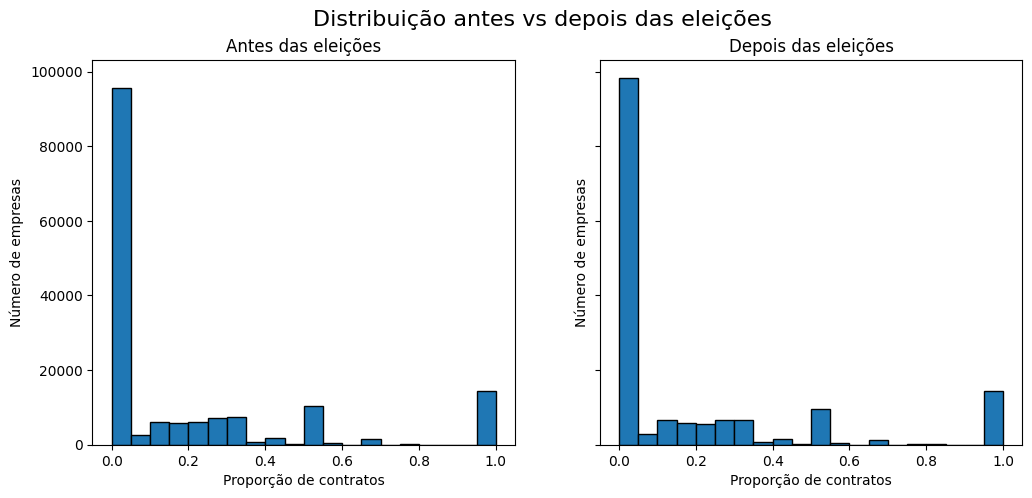

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

axes[0].hist(
    risco_eleitoral_empresas["rating_antes"].dropna(),
    bins=20,
    edgecolor="black"
)
axes[0].set_title("Antes das eleições")

axes[1].hist(
    risco_eleitoral_empresas["rating_depois"].dropna(),
    bins=20,
    edgecolor="black"
)
axes[1].set_title("Depois das eleições")

for ax in axes:
    ax.set_xlabel("Proporção de contratos")
    ax.set_ylabel("Número de empresas")

plt.suptitle("Distribuição antes vs depois das eleições", fontsize=16)
plt.show()

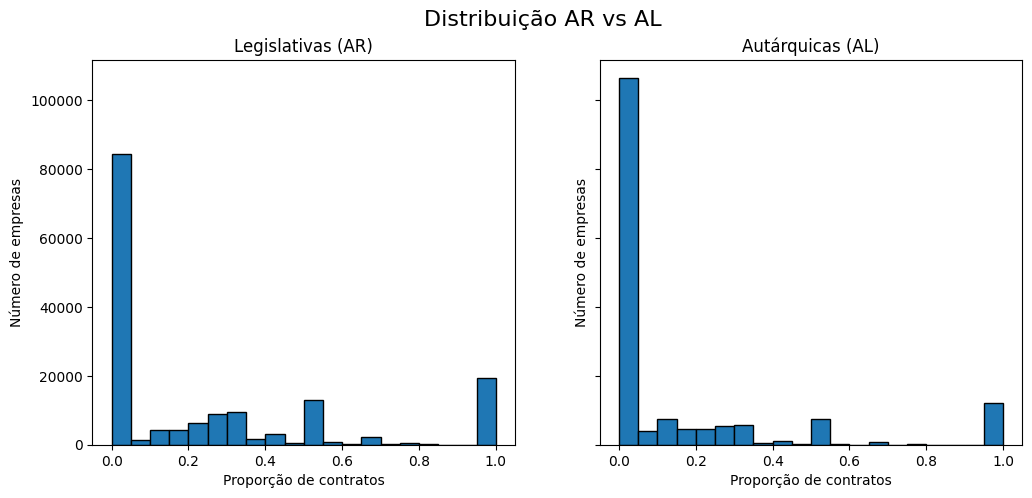

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

axes[0].hist(
    risco_eleitoral_empresas["rating_AR"].dropna(),
    bins=20,
    edgecolor="black"
)
axes[0].set_title("Legislativas (AR)")

axes[1].hist(
    risco_eleitoral_empresas["rating_AL"].dropna(),
    bins=20,
    edgecolor="black"
)
axes[1].set_title("Autárquicas (AL)")

for ax in axes:
    ax.set_xlabel("Proporção de contratos")
    ax.set_ylabel("Número de empresas")

plt.suptitle("Distribuição AR vs AL", fontsize=16)
plt.show()

In [64]:
media_AR = risco_eleitoral_empresas["rating_AR"].mean()
media_AL = risco_eleitoral_empresas["rating_AL"].mean()

print("Média AR:", media_AR)
print("Média AL:", media_AL)

Média AR: 0.24250067465406622
Média AL: 0.14700166302373785


## 8.3.7 Concentração de empresas por CPV


In [65]:
#rácio de contratos de uma empresa relativo a todos desse CPV
if {"adjudicatarios", "setor_cpv"}.issubset(df.columns):
    df_cpv = (
        df.dropna(subset=["adjudicatarios", "setor_cpv"])
          .groupby(["setor_cpv", "adjudicatarios"])
          .size()
          .reset_index(name="n_contratos_empresa_cpv")
    )

    totais_cpv = (
        df.dropna(subset=["setor_cpv"])
          .groupby("setor_cpv")
          .size()
          .reset_index(name="n_total_cpv")
    )

    df_cpv = df_cpv.merge(totais_cpv, on="setor_cpv", how="left")
    df_cpv["ratio_concentracao_cpv"] = (
        df_cpv["n_contratos_empresa_cpv"] / df_cpv["n_total_cpv"]
    )

    score_cpv_empresa = (
        df_cpv.groupby("adjudicatarios")["ratio_concentracao_cpv"]
        .max()
    )

    df_empresas["score_concentracao_cpv"] = (
        df_empresas["empresa"].map(score_cpv_empresa).fillna(0)
    )

    display(
        df_empresas[["empresa", "score_concentracao_cpv"]]
        .sort_values("score_concentracao_cpv", ascending=False)
        .head(20)
    )
else:
    print("Faltam colunas necessárias para calcular concentração por CPV.")
    df_empresas["score_concentracao_cpv"] = 0

,empresa,score_concentracao_cpv
231,"504615947, MEO SERVICOS DE COMUNICACOES E MULT...",0.376344
601,"500697370, PETROLEOS DE PORTUGAL PETROGAL",0.239497
39878,"506019608, SMILE VIAGENS E TURISMO",0.226518
245,"502544180, VODAFONE PORTUGAL COMUNICACOES PESS...",0.199004
1474,"500918880, FIDELIDADE CA DE SEGUROS",0.143595
457,"502604751, NOS COMUNICACOES",0.141762
281,"503504564, EDP COMERCIAL COMERCIALIZACAO DE EN...",0.115762
1094,"500183872, MARIO GONCALVES",0.115456
1294,"500940231, GENERALI SEGUROS",0.110790
593,"504723456, GALP POWE",0.085624


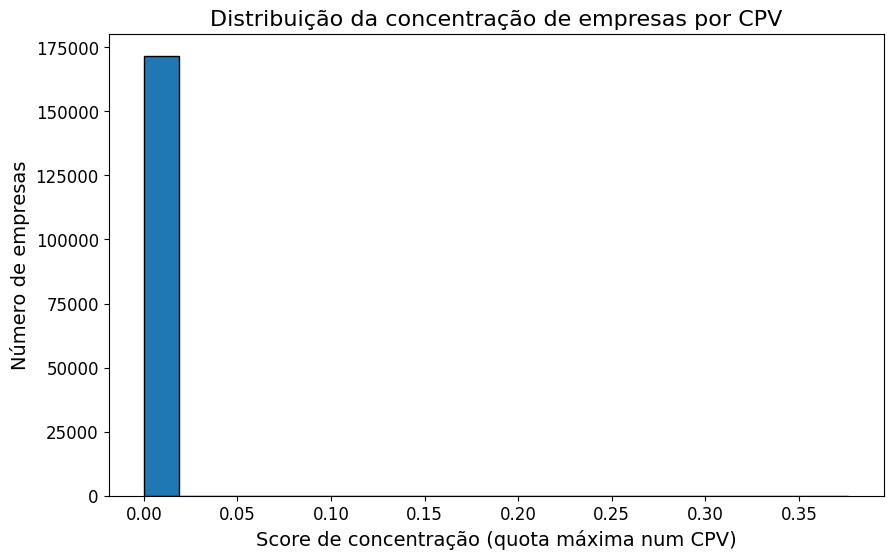

In [66]:
plt.figure(figsize=(10,6))

plt.hist(
    df_empresas["score_concentracao_cpv"].dropna(),
    bins=20,
    edgecolor="black"
)


plt.title("Distribuição da concentração de empresas por CPV", fontsize=16)
plt.xlabel("Score de concentração (quota máxima num CPV)", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

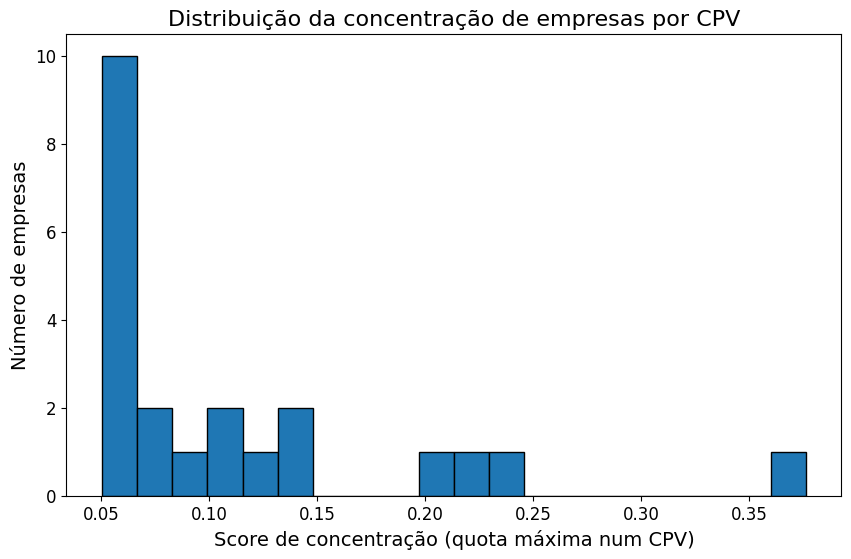

In [67]:
# remover extremos fixos
df_filtrado = df_empresas[
    (df_empresas["score_concentracao_cpv"] > 0.05) &
    (df_empresas["score_concentracao_cpv"] < 0.95)
]

plt.figure(figsize=(10,6))

plt.hist(
    df_filtrado["score_concentracao_cpv"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.title("Distribuição da concentração de empresas por CPV", fontsize=16)
plt.xlabel("Score de concentração (quota máxima num CPV)", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [68]:
# encontrar o CPV onde cada empresa tem maior concentração
idx_max = (
    df_cpv.groupby("adjudicatarios")["ratio_concentracao_cpv"]
    .idxmax()
)

cpv_principal = (
    df_cpv.loc[
        idx_max,
        ["adjudicatarios", "setor_cpv", "ratio_concentracao_cpv"]
    ]
    .rename(columns={
        "adjudicatarios": "empresa",
        "setor_cpv": "cpv_principal"
    })
)

# juntar ao df_empresas
df_top = (
    df_empresas.merge(
        cpv_principal[["empresa", "cpv_principal"]],
        on="empresa",
        how="left"
    )
)

# top 10
top10_concentracao = (
    df_top[
        [
            "empresa",
            "score_concentracao_cpv",
            "total_contratos",
            "cpv_principal"
        ]
    ]
    .sort_values(
        ["score_concentracao_cpv", "total_contratos"],
        ascending=[False, False]
    )
    .head(10)
)

display(top10_concentracao)

,empresa,score_concentracao_cpv,total_contratos,cpv_principal
231,"504615947, MEO SERVICOS DE COMUNICACOES E MULT...",0.376344,7982.0,64
601,"500697370, PETROLEOS DE PORTUGAL PETROGAL",0.239497,5811.0,09
39878,"506019608, SMILE VIAGENS E TURISMO",0.226518,5782.0,63
245,"502544180, VODAFONE PORTUGAL COMUNICACOES PESS...",0.199004,3053.0,64
1474,"500918880, FIDELIDADE CA DE SEGUROS",0.143595,2610.0,66
457,"502604751, NOS COMUNICACOES",0.141762,2682.0,64
281,"503504564, EDP COMERCIAL COMERCIALIZACAO DE EN...",0.115762,2900.0,65
1094,"500183872, MARIO GONCALVES",0.115456,538.0,41
1294,"500940231, GENERALI SEGUROS",0.110790,2004.0,66
593,"504723456, GALP POWE",0.085624,1740.0,76


In [69]:
df_empresas.to_pickle("df_empresas.pkl")
risco_eleitoral_empresas.to_pickle("risco_eleitoral_empresas.pkl")

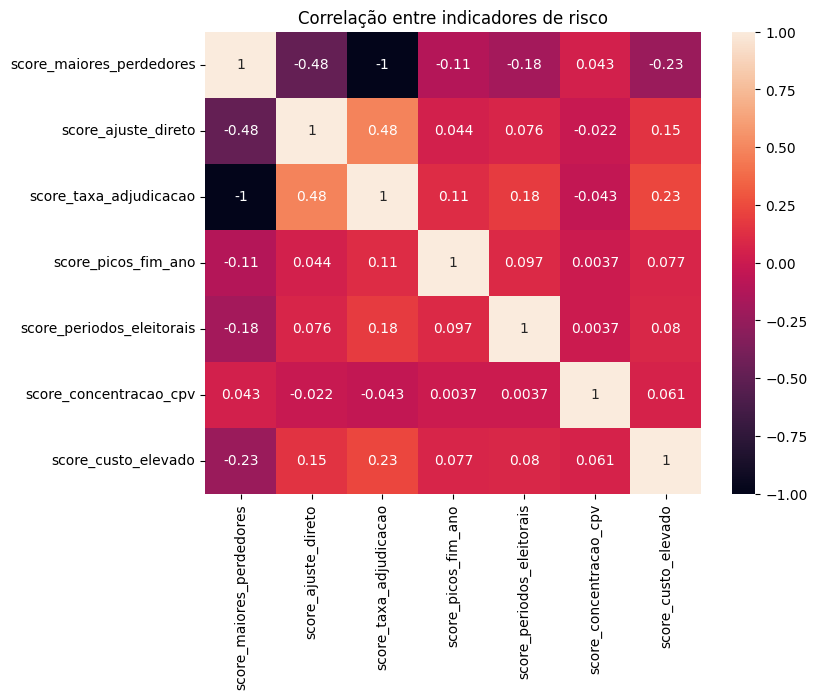

In [70]:
scores = [
    "score_maiores_perdedores",
    "score_ajuste_direto",
    "score_taxa_adjudicacao",
    "score_picos_fim_ano",
    "score_periodos_eleitorais",
    "score_concentracao_cpv",
    "score_custo_elevado"
]

corr = df_empresas[scores].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlação entre indicadores de risco")
plt.show()

In [71]:
# =====================================================
# 8.4 ÍNDICE GLOBAL DE RISCO DE FRAUDE
# =====================================================

# Scores individuais utilizados no índice
score_cols = [
    "score_maiores_perdedores",
    "score_ajuste_direto",
    "score_taxa_adjudicacao",
    "score_picos_fim_ano",
    "score_periodos_eleitorais",
    "score_concentracao_cpv",
    "score_custo_elevado"
]

# =====================================================
# 1. NORMALIZAÇÃO DOS SCORES
# =====================================================

for col in score_cols:

    df_empresas[col] = (
        pd.to_numeric(df_empresas[col], errors="coerce")
        .fillna(0)
    )

    # caso estejam numa escala 0-10
    if df_empresas[col].max() > 1:
        df_empresas[col] = df_empresas[col] / 10

    df_empresas[col] = df_empresas[col].clip(0, 1)

# =====================================================
# 2. DINÂMICA DE PARTICIPAÇÃO
# =====================================================
# score_maiores_perdedores e score_taxa_adjudicacao
# representam padrões opostos da mesma dimensão

df_empresas["score_dinamica_participacao"] = (
    df_empresas[
        [
            "score_maiores_perdedores",
            "score_taxa_adjudicacao"
        ]
    ]
    .max(axis=1)
)

# =====================================================
# 3. ÍNDICE BASE
# =====================================================

df_empresas["indice_base_risco"] = (
    df_empresas["score_dinamica_participacao"] +
    df_empresas["score_ajuste_direto"] +
    df_empresas["score_custo_elevado"] +
    df_empresas["score_picos_fim_ano"] +
    df_empresas["score_periodos_eleitorais"] +
    df_empresas["score_concentracao_cpv"]
) / 6

# =====================================================
# 4. INTERAÇÕES ENTRE PADRÕES DE RISCO
# =====================================================

df_empresas["int_ad_pe"] = (
    df_empresas["score_ajuste_direto"] *
    df_empresas["score_periodos_eleitorais"]
) ** 2

df_empresas["int_ad_fa"] = (
    df_empresas["score_ajuste_direto"] *
    df_empresas["score_picos_fim_ano"]
) ** 2

df_empresas["int_dp_cpv"] = (
    df_empresas["score_dinamica_participacao"] *
    df_empresas["score_concentracao_cpv"]
) ** 2

df_empresas["int_ad_ce"] = (
    df_empresas["score_ajuste_direto"] *
    df_empresas["score_custo_elevado"]
) ** 2

# índice médio das interações

df_empresas["indice_interacoes"] = (
    df_empresas["int_ad_pe"] +
    df_empresas["int_ad_fa"] +
    df_empresas["int_dp_cpv"] +
    df_empresas["int_ad_ce"]
) / 4

# =====================================================
# 5. ÍNDICE GLOBAL DE RISCO DE FRAUDE
# =====================================================

df_empresas["IGRF"] = (
    0.80 * df_empresas["indice_base_risco"] +
    0.20 * df_empresas["indice_interacoes"]
)

df_empresas["IGRF"] = (
    df_empresas["IGRF"]
    .clip(0, 1)
)

# =====================================================
# 6. CLASSIFICAÇÃO DO RISCO
# =====================================================

df_empresas["classe_risco"] = pd.cut(
    df_empresas["IGRF"],
    bins=[-0.01, 0.25, 0.50, 0.75, 1.00],
    labels=[
        "Reduzido",
        "Moderado",
        "Elevado",
        "Muito Elevado"
    ]
)

# =====================================================
# 7. CPV PRINCIPAL DE CADA EMPRESA
# =====================================================

cpv_empresa = (
    df.dropna(subset=["adjudicatarios", "setor_cpv"])
    .groupby(["adjudicatarios", "setor_cpv"])
    .size()
    .reset_index(name="n_contratos_cpv")
)

idx = (
    cpv_empresa
    .groupby("adjudicatarios")["n_contratos_cpv"]
    .idxmax()
)

cpv_principal = (
    cpv_empresa.loc[idx, ["adjudicatarios", "setor_cpv"]]
    .rename(columns={
        "adjudicatarios": "empresa",
        "setor_cpv": "cpv_principal"
    })
)

# =====================================================
# 8. RESULTADO FINAL
# =====================================================
resultado_risco_global = (
    df_empresas[
        [
            "empresa",
            "IGRF",
            "total_participacoes"
        ]
    ]
    .merge(
        cpv_principal,
        on="empresa",
        how="left"
    )
    .sort_values(
        ["IGRF", "total_participacoes"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(resultado_risco_global.head(20))

,empresa,IGRF,total_participacoes,cpv_principal
0,ALEXION PHARMA SPAIN EM PORTUGAL,0.815875,1.0,33
1,MANTIS DEPOSITION GMBH,0.815856,1.0,31
2,DFAS,0.815851,2.0,22
3,INTEGRATED BIOMETRICS LCC,0.815775,1.0,30
4,ARBIT CYBER DEFENCE SYSTEMS APS,0.815766,1.0,35
5,"500287937, TRANSPORTES AZEVEDO",0.815719,1.0,65
6,OPTOMET GMBH,0.815662,1.0,38
7,APICE FIRENZE S R L,0.815658,1.0,92
8,"514512644, ENQUANTO DESCANSA",0.815608,1.0,85
9,PER VICES CORPORATION,0.815606,1.0,38


In [72]:
# top 20 empresas com mais de 10 participações
resultado_risco_global = (
    df_empresas[
        df_empresas["total_participacoes"] > 10
    ][
        [
            "empresa",
            "IGRF",
            "total_participacoes"
        ]
    ]
    .merge(
        cpv_principal,
        on="empresa",
        how="left"
    )
    .sort_values(
        ["IGRF", "total_participacoes"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(resultado_risco_global.head(20))

,empresa,IGRF,total_participacoes,cpv_principal
0,"509177581, EDUMANIA",0.798947,13.0,80
1,"516145410, FRESCOGABARITO",0.783163,33.0,90
2,"502204010, ELECTROLINHAS MONTAGENS ELECTRICAS",0.754949,14.0,71
3,"514108649, TRACK PROFIT ENERGY",0.753798,28.0,51
4,"505746662, SANVITEXTEIS II CONFECCOES E SERVICOS",0.749465,12.0,18
5,"500148392, JAYME DA COSTA ENERGIA E SISTEMAS",0.742624,18.0,45
6,"515467561, BURGO TRANSITORIO",0.718445,29.0,71
7,"503842060, EGITRON ENGENHARIA E AUTOMACAO INDU...",0.695827,20.0,42
8,"518590542, MESTRIA AO RUBRO",0.691232,11.0,71
9,"501233865, A H BOMBEIROS VOLUNTARIOS DE BOTICAS",0.683670,59.0,60


In [73]:
# top 20 empresas com mais de 50 participações
resultado_risco_global = (
    df_empresas[
        df_empresas["total_participacoes"] > 50
    ][
        [
            "empresa",
            "IGRF",
            "total_participacoes"
        ]
    ]
    .merge(
        cpv_principal,
        on="empresa",
        how="left"
    )
    .sort_values(
        ["IGRF", "total_participacoes"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(resultado_risco_global.head(20))

,empresa,IGRF,total_participacoes,cpv_principal
0,"501233865, A H BOMBEIROS VOLUNTARIOS DE BOTICAS",0.683670,59.0,60
1,"501110070, ASSOCIACAO HUMANITARIA DE BOMBEIROS...",0.663581,118.0,85
2,"515343242, COMPANHIA DOS CABAZES",0.661794,112.0,15
3,"516715046, IDEAL PRODUTOS E SERVICOS",0.660536,60.0,90
4,"504567853, AMBULANCIAS MIRANDELENSE",0.643901,88.0,85
5,"501140050, ASSOCIACAO HUMANITARIA DE BOMBEIROS...",0.642041,70.0,85
6,"505028700, ASSOC HUMAN BOMB VOL ORTIGOSA",0.635093,266.0,60
7,"501386246, ASSOCIACAO HUMANITARIA DOS BOMBEIRO...",0.621231,538.0,85
8,EXTRAICE,0.620680,53.0,37
9,"503116289, DAVION INDUSTRIA DE VESTUARIO",0.620190,59.0,33


In [74]:
# top 20 empresas com mais de 150 participações

resultado_risco_global = (
    df_empresas[
        df_empresas["total_participacoes"] > 150
    ][
        [
            "empresa",
            "IGRF",
            "total_participacoes"
        ]
    ]
    .merge(
        cpv_principal,
        on="empresa",
        how="left"
    )
    .sort_values(
        ["IGRF", "total_participacoes"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(resultado_risco_global.head(20))

,empresa,IGRF,total_participacoes,cpv_principal
0,"505028700, ASSOC HUMAN BOMB VOL ORTIGOSA",0.635093,266.0,60
1,"501386246, ASSOCIACAO HUMANITARIA DOS BOMBEIRO...",0.621231,538.0,85
2,"503623679, A H BOMBEIROS VOLUNT DE CRESTUMA",0.614995,385.0,85
3,"503644650, ASSOCIACAO SOCORROS FREGUESIA TURCIFAL",0.611550,349.0,60
4,"500986207, A H BOMBEIROS VOLUNT OLIVEIRA DE AZ...",0.610194,443.0,85
5,"501438157, ASSOCIACAO HUMANITARIA AMBULANCIAS ...",0.608804,238.0,60
6,"502590181, ASSOCIACOA DOS VOLUNTARIOS DE CAIDE...",0.608217,482.0,85
7,"501808965, ASSOCIACAO SOCORROS FREIRIA",0.606895,296.0,60
8,"518028135, CELLTRION PORTUGAL",0.606613,242.0,33
9,"502125950, ASSOC HUMAN BOMB VOL BENEDITA",0.606272,268.0,60


In [75]:
# top 20 empresas com mais de 500 participações

resultado_risco_global = (
    df_empresas[
        df_empresas["total_participacoes"] > 500
    ][
        [
            "empresa",
            "IGRF",
            "total_participacoes"
        ]
    ]
    .sort_values(
        ["IGRF", "total_participacoes"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(resultado_risco_global.head(20))

,empresa,IGRF,total_participacoes
0,"501386246, ASSOCIACAO HUMANITARIA DOS BOMBEIRO...",0.621231,538.0
1,"500900108, BOMBEIROS VOLUNTARIOS COIMBROES",0.588244,705.0
2,"501328009, BOMBEIROS VOLUNTARIOS DOS CARVALHOS",0.577450,600.0
3,"501123598, ASSOCIACAO HUMANITARIA BOMBEIROS VO...",0.574281,505.0
4,"501542760, CORPO DE SALVACAO PUBLICA DE VALPAC...",0.574228,514.0
5,"501060391, BOMBEIROS VOLUNTARIOS DE AVINTES",0.571579,537.0
6,"506019608, SMILE VIAGENS E TURISMO",0.554046,6225.0
7,"506303004, ALTER GENERICOS",0.542867,952.0
8,"516125885, USV MED",0.539823,2216.0
9,"505826801, EUROSAFE",0.534950,941.0


In [76]:
df_top_setor = df.merge(
    df_empresas[["empresa", "IGRF", "classe_risco"]],
    left_on="adjudicatarios",
    right_on="empresa",
    how="left"
)

risco_por_setor = (
    df_top_setor.dropna(subset=["setor_cpv", "IGRF"])
    .groupby("setor_cpv")
    .agg(
        n_contratos=("idcontrato", "count"),
        n_empresas=("adjudicatarios", "nunique"),
        IGRF_medio=("IGRF", "mean"),
        IGRF_mediano=("IGRF", "median")
    )
    .sort_values("IGRF_medio", ascending=False)
    .reset_index()
)

display(risco_por_setor.head(20))

,setor_cpv,n_contratos,n_empresas,IGRF_medio,IGRF_mediano
0,63,18674,1784,0.474448,0.470265
1,64,12648,750,0.466033,0.469429
2,33,523259,6236,0.455111,0.462966
3,55,19841,4775,0.452436,0.458200
4,32,13736,2857,0.450026,0.451673
5,09,21942,1627,0.447299,0.452415
6,70,1150,541,0.446685,0.452571
7,38,15080,2481,0.445483,0.448511
8,48,22100,2655,0.443334,0.448650
9,43,2940,1159,0.442370,0.446447


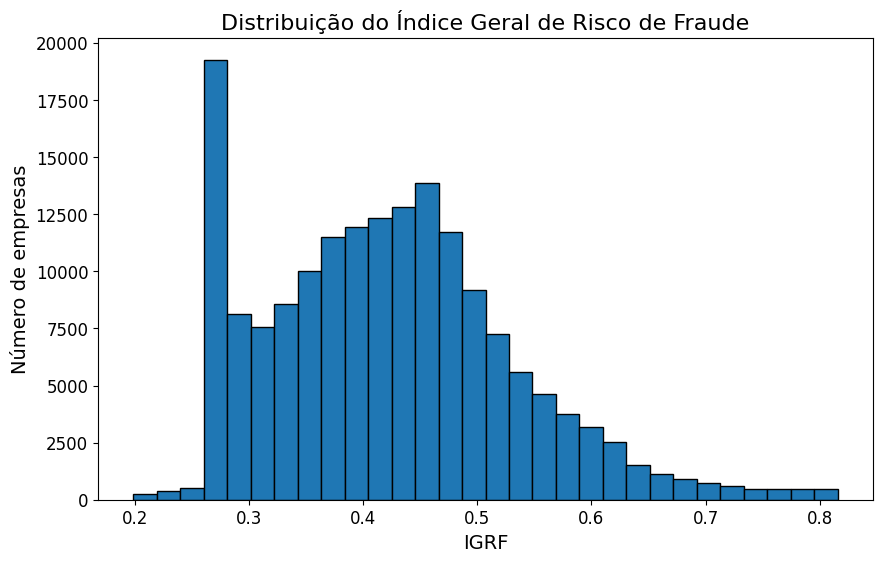

In [77]:

plt.figure(figsize=(10,6))

plt.hist(
    df_empresas["IGRF"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribuição do Índice Geral de Risco de Fraude", fontsize=16)
plt.xlabel("IGRF", fontsize=14)
plt.ylabel("Número de empresas", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

classe_risco
Moderado         134216
Elevado           35203
Muito Elevado      1512
Reduzido            867
Name: count, dtype: int64

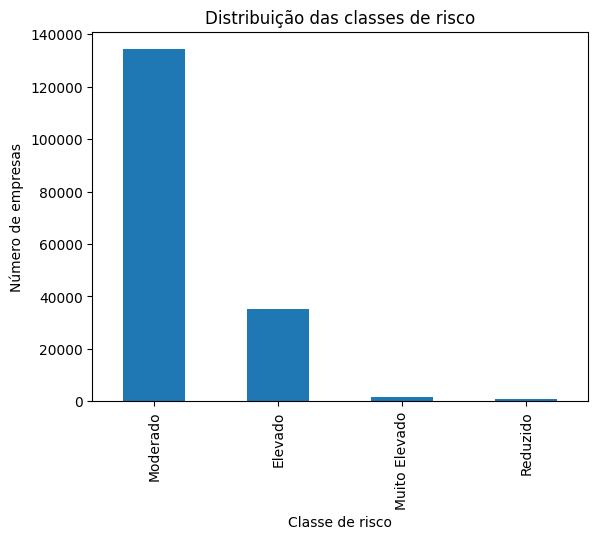

In [78]:
classe_counts = (
    df_empresas["classe_risco"]
    .value_counts()
)

display(classe_counts)

classe_counts.plot(kind="bar")

plt.title("Distribuição das classes de risco")
plt.xlabel("Classe de risco")
plt.ylabel("Número de empresas")

plt.show()

In [79]:


# -----------------------------
# 1. Definir grupos de análise
# -----------------------------

grupos = {
    "Top 3 | >10 participações": 10,
    "Top 3 | >50 participações": 50,
    "Top 3 | >150 participações": 150
}

empresas_alvo = []

for nome_grupo, limite in grupos.items():
    
    top3 = (
        df_empresas[df_empresas["total_participacoes"] > limite]
        .merge(cpv_principal, on="empresa", how="left")
        .sort_values(["IGRF", "total_participacoes"], ascending=[False, False])
        .head(3)
        .copy()
    )
    
    top3["grupo_analise"] = nome_grupo
    empresas_alvo.append(top3)

empresas_alvo = pd.concat(empresas_alvo, ignore_index=True)

display(empresas_alvo[
    ["grupo_analise", "empresa", "IGRF", "total_participacoes", "cpv_principal"]
])

,grupo_analise,empresa,IGRF,total_participacoes,cpv_principal
0,Top 3 | >10 participações,"509177581, EDUMANIA",0.798947,13.0,80
1,Top 3 | >10 participações,"516145410, FRESCOGABARITO",0.783163,33.0,90
2,Top 3 | >10 participações,"502204010, ELECTROLINHAS MONTAGENS ELECTRICAS",0.754949,14.0,71
3,Top 3 | >50 participações,"501233865, A H BOMBEIROS VOLUNTARIOS DE BOTICAS",0.683670,59.0,60
4,Top 3 | >50 participações,"501110070, ASSOCIACAO HUMANITARIA DE BOMBEIROS...",0.663581,118.0,85
5,Top 3 | >50 participações,"515343242, COMPANHIA DOS CABAZES",0.661794,112.0,15
6,Top 3 | >150 participações,"505028700, ASSOC HUMAN BOMB VOL ORTIGOSA",0.635093,266.0,60
7,Top 3 | >150 participações,"501386246, ASSOCIACAO HUMANITARIA DOS BOMBEIRO...",0.621231,538.0,85
8,Top 3 | >150 participações,"503623679, A H BOMBEIROS VOLUNT DE CRESTUMA",0.614995,385.0,85


In [ ]:
# =====================================================
# 2. Criar base de contratos das empresas alvo
# =====================================================

lista_empresas = empresas_alvo["empresa"].unique()

df_empresas_contratos = df[
    df["adjudicatarios"].isin(lista_empresas)
].copy()

# Garantir datas
if "dataPublicacao" in df_empresas_contratos.columns:
    df_empresas_contratos["dataPublicacao"] = pd.to_datetime(
        df_empresas_contratos["dataPublicacao"],
        errors="coerce"
    )
    df_empresas_contratos["ano"] = df_empresas_contratos["dataPublicacao"].dt.year
    df_empresas_contratos["mes"] = df_empresas_contratos["dataPublicacao"].dt.month


# =====================================================
# 3. Resumo quantitativo por empresa
# =====================================================

resumo_empresas = (
    df_empresas_contratos
    .groupby("adjudicatarios")
    .agg(
        n_contratos=("idcontrato", "nunique"),
        valor_total=("precoContratual_2025", "sum"),
        valor_medio=("precoContratual_2025", "mean"),
        valor_mediano=("precoContratual_2025", "median"),
        prazo_medio=("prazoExecucao", "mean"),
        prazo_mediano=("prazoExecucao", "median"),
        n_adjudicantes=("adjudicante", "nunique"),
        n_cpv=("setor_cpv", "nunique")
    )
    .reset_index()
    .rename(columns={"adjudicatarios": "empresa"})
)

# Juntar métricas do índice
colunas_scores = [
    "empresa",
    "IGRF",
    "classe_risco",
    "total_participacoes",
    "total_adjudicatario",
    "total_concorrente",
    "score_maiores_perdedores",
    "score_taxa_adjudicacao",
    "score_ajuste_direto",
    "score_picos_fim_ano",
    "score_periodos_eleitorais",
    "score_concentracao_cpv",
    "score_custo_elevado",
    "score_dinamica_participacao",
    "indice_base_risco",
    "indice_interacoes"
]

colunas_scores = [c for c in colunas_scores if c in df_empresas.columns]

resumo_empresas = resumo_empresas.merge(
    df_empresas[colunas_scores],
    on="empresa",
    how="left"
)

resumo_empresas = resumo_empresas.merge(
    empresas_alvo[["empresa", "grupo_analise", "cpv_principal"]],
    on="empresa",
    how="left"
)

# Percentagem de ajuste direto, se existir
if "ratio_ajuste" in df_empresas.columns:
    resumo_empresas = resumo_empresas.merge(
        df_empresas[["empresa", "ratio_ajuste", "ajustes_diretos"]],
        on="empresa",
        how="left"
    )

# Ordenar
resumo_empresas = resumo_empresas.sort_values(
    ["grupo_analise", "IGRF"],
    ascending=[True, False]
)

display(resumo_empresas)

,empresa,n_contratos,valor_total,valor_medio,valor_mediano,prazo_medio,prazo_mediano,n_adjudicantes,n_cpv,IGRF,...,score_periodos_eleitorais,score_concentracao_cpv,score_custo_elevado,score_dinamica_participacao,indice_base_risco,indice_interacoes,grupo_analise,cpv_principal,ratio_ajuste,ajustes_diretos
6,"509177581, EDUMANIA",1,7.844530e+04,78445.302989,78445.302989,244.000000,244.0,1,1,0.798947,...,1.000000,0.000026,0.988511,0.923077,0.816742,0.727766,Top 3 | >10 participações,80,0.000000,0.0
8,"516145410, FRESCOGABARITO",1,2.355639e+04,23556.385628,23556.385628,61.000000,61.0,1,1,0.783163,...,1.000000,0.000024,0.873189,0.969697,0.806874,0.688317,Top 3 | >10 participações,90,1.000000,1.0
3,"502204010, ELECTROLINHAS MONTAGENS ELECTRICAS",1,3.836811e+05,383681.079479,383681.079479,215.000000,215.0,1,1,0.754949,...,1.000000,0.000013,0.785244,0.928571,0.783778,0.639631,Top 3 | >10 participações,71,0.000000,0.0
5,"505028700, ASSOC HUMAN BOMB VOL ORTIGOSA",15,8.611011e+05,57406.740000,73657.610000,96.133333,31.0,3,2,0.635093,...,0.933333,0.000323,0.952365,0.943609,0.680856,0.452043,Top 3 | >150 participações,60,0.000000,0.0
2,"501386246, ASSOCIACAO HUMANITARIA DOS BOMBEIRO...",17,1.075558e+06,63268.112115,2610.760000,120.588235,5.0,4,2,0.621231,...,0.823529,0.000411,0.962069,0.968401,0.673048,0.413962,Top 3 | >150 participações,85,0.176471,3.0
4,"503623679, A H BOMBEIROS VOLUNT DE CRESTUMA",12,1.821733e+05,15181.108333,7936.575000,35.000000,5.0,1,1,0.614995,...,0.583333,0.000308,0.993085,0.968831,0.672399,0.385375,Top 3 | >150 participações,85,0.000000,0.0
1,"501233865, A H BOMBEIROS VOLUNTARIOS DE BOTICAS",2,4.880634e+03,2440.317182,2440.317182,2.500000,2.5,2,2,0.683670,...,0.500000,0.000032,0.910340,0.966102,0.727552,0.508144,Top 3 | >50 participações,60,0.000000,0.0
0,"501110070, ASSOCIACAO HUMANITARIA DE BOMBEIROS...",2,7.392800e+02,369.640000,369.640000,5.000000,5.0,1,1,0.663581,...,1.000000,0.000051,0.248855,0.983051,0.703466,0.504039,Top 3 | >50 participações,85,0.000000,0.0
7,"515343242, COMPANHIA DOS CABAZES",33,1.008475e+06,30559.837722,15876.960000,22.393939,20.0,27,2,0.661794,...,0.636364,0.000504,0.942723,0.705357,0.697352,0.519561,Top 3 | >50 participações,15,0.212121,7.0
